In [ ]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

Not running in Colab; skipping Drive mount and install steps.


# Trabalho 3 — Marcas d’Água em Dados para Auditoria de Modelos Generativos

> **Pergunta central:** como podemos marcar um conjunto de dados de forma que, se ele for usado no treinamento de um modelo generativo, seja possível auditar posteriormente esse uso?

Neste trabalho usaremos **Variational Autoencoder** como nosso método generativo base, e investigaremos estratégias para **auditoria de uso de dados em modelos generativos**. A situação é a seguinte: o dono de uma base de dados disponibiliza um conjunto de imagens, mas quer preservar a capacidade de verificar, posteriormente, se essas imagens foram usadas por terceiros no treinamento de um modelo generativo.

Para isso, vamos estudar a ideia de inserir uma **marca d’água nos dados de treino**.
Vamos fazer esse estudo usando os dados do MNIST.

Exploraremos duas estratégias:
1. **Marca visível** — patch fixo no canto da imagem. Fácil de detectar, trivialmente removível.
2. **Marca spread-spectrum** — textura pseudo-aleatória de baixa amplitude. Idealmente imperceptível ao olho, detectável via correlação com a chave secreta.

E faremos um **estudo de ablação** variando amplitude, fração marcada e o número de amostras usadas para a auditoria.

**Entregáveis.**
1. Notebook preenchido e executado.
2. Pesos dos VAEs treinados (limpo, marca visível, marca spread-spectrum).
3. Respostas das questões com evidências numéricas dos seus próprios resultados.

**Regras.** Use PyTorch. Fixe seeds. Não apague células do enunciado.

## Parte 0 — Setup e reprodutibilidade

**Tarefa 0.1.** Fixe as seeds aleatórias e configure o dispositivo.

**Tarefa 0.2.** Imprima as versões de `torch` e `torchvision`.

**Tarefa 0.3.** Defina `student_run_tag` (suas iniciais + data) — use ao salvar artefatos.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

SEED       = 42    # semente do experimentador: splits, pesos, etc.
OWNER_SEED = 1234  # semente do dono dos dados: gera o padrão secreto

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

student_run_tag = "BZA_08_06"   # ex: "DA_2026-05-22"
output_dir = Path("trabalho3_outputs") / student_run_tag
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {output_dir}")

Dispositivo: cpu
Torch: 2.11.0+cpu  |  Torchvision: 0.26.0+cpu
Output dir: trabalho3_outputs/BZA_02_06


## Parte 1 — VAE no MNIST

Antes de pensar em marca d'água, precisamos de um modelo generativo razoável. Vamos construir um VAE simples no MNIST.

### 1.1 Dados

**Tarefa 1.1.** Carregue o MNIST de treino e teste com `torchvision.datasets.MNIST` (transformação: apenas `ToTensor()`).

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

#Fazer download do dataset e criar o dataloader
train_ds = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
test_ds = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

BATCH_SIZE = 256
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True # set to True to drop the last incomplete batch, if the dataset size is not divisible by the batch size
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False # If False and the size of dataset is not divisible by the batch size, then the last batch will be smaller.
)

print(f"Treino: {len(train_ds):,}  |  Teste: {len(test_ds):,}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 2.59MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.12MB/s]


Treino: 60,000  |  Teste: 10,000


### 1.2 Arquitetura do VAE

Um VAE é composto por:
- **Encoder** $q_\phi(z \mid x)$: projeta a imagem no espaço latente, produzindo $\mu$ e $\log\sigma^2$.
- **Reparametrização**: $z = \mu + \sigma \odot \epsilon$, $\epsilon \sim \mathcal{N}(0, I)$.
- **Decoder** $p_\theta(x \mid z)$: reconstrói a imagem a partir de $z$ (saída em $[0,1]$ via sigmoid).

**Tarefa 1.2.** Implemente `Encoder`, `Decoder`, `VAE`. Use uma MLP simples (camadas escondidas de 512 e 256 unidades com ReLU). A dimensão latente (`LATENT_DIM`) é um hiperparâmetro configurável — para MNIST, valores entre 2 e 32 produzem modelos razoáveis.

In [3]:
# Escolhido com base na busca de hiperparâmetros no apêndice A
LATENT_DIM = 16   # escolha um valor razoável (sugestão: entre 2 e 32 para MNIST)
IMG_DIM = 28 * 28

class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        # TODO: definir self.net (Linear 784→512→256 com ReLU)
        self.net = nn.Sequential(
            nn.Linear(IMG_DIM, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        # TODO: definir self.fc_mu e self.fc_log_var (256 → latent_dim)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

        # raise NotImplementedError("Implemente Encoder.__init__")

    def forward(self, x):
        # TODO: achatar x, passar pela net, retornar (mu, log_var)
        x = x.flatten(start_dim=1)
        x = self.net(x)

        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        return mu, log_var
        # raise NotImplementedError("Implemente Encoder.forward")


class Decoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        # TODO: definir self.net (Linear latent_dim→256→512→784 com ReLU; sigmoid no final)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, IMG_DIM),
            nn.Sigmoid()
        )
        # raise NotImplementedError("Implemente Decoder.__init__")

    def forward(self, z):
        # TODO: aplicar self.net e reshape para (-1, 1, 28, 28)
        x_hat = self.net(z)
        x_hat = x_hat.reshape(-1, 1, 28, 28)
        return x_hat
        # raise NotImplementedError("Implemente Decoder.forward")


class VAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparametrize(self, mu, log_var):
        # TODO: implementar o truque da reparametrização
        # z = \mu + \sigma \odot \epsilon, onde \epsilon ~ N(0, I)
        std = torch.exp(0.5 * log_var)  # \log\sigma^2 -> \sigma
        eps = torch.randn_like(std)  # amostra de ruído \epsilon ~ N(0, I)
        z = mu + std * eps  # reparametrização
        return z
        # raise NotImplementedError("Implemente reparametrize")

    def forward(self, x):
        # TODO: encode, sample, decode; retornar (x_hat, mu, log_var)
        mu, log_var = self.encoder(x)
        z = self.reparametrize(mu, log_var)
        x_hat = self.decoder(z)

        return x_hat, mu, log_var
        # raise NotImplementedError("Implemente VAE.forward")


model = VAE(LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"LATENT_DIM = {LATENT_DIM}  |  Parâmetros: {n_params:,}")

LATENT_DIM = 16  |  Parâmetros: 1,079,600


### 1.3 Função de perda — ELBO

O VAE maximiza o **Evidence Lower Bound (ELBO)**:

$$\mathcal{L}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x \mid z)]}_{\text{reconstrução}} - \underbrace{D_{KL}(q_\phi(z|x) \,\|\, p(z))}_{\text{regularização}}$$

Para imagens com pixels em $[0,1]$, usamos **BCE** (Bernoulli) como modelo de reconstrução. Como prior, $p(z) = \mathcal{N}(0, I)$, e a KL tem forma fechada:

$$D_{KL}(q_\phi(z|x) \| \mathcal{N}(0,I)) = -\frac{1}{2}\sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

**Tarefa 1.3.** Implemente `vae_loss` que retorna `(loss_total, recon, kl)`. Use BCE com `reduction="sum"` (some sobre pixels e batch).

In [4]:
def vae_loss(x, x_hat, mu, log_var):
    # TODO: BCE entre x_hat e x (reduction="sum")
    recon = nn.BCELoss(reduction="sum")(x_hat, x)
    # TODO: KL fechada para prior N(0, I)
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    # TODO: retornar (loss_total, recon, kl)
    loss_total = recon + kl
    return loss_total, recon, kl
    # raise NotImplementedError("Implemente vae_loss")

### 1.4 Treinamento

Treine por **30 épocas** com Adam (lr=1e-3). A loss é a ELBO (somada sobre o batch, dividida no final por `len(dataset)` para reportar por amostra).

**Tarefa 1.4.** Implemente o loop de treino e salve o histórico de loss/recon/KL para treino e teste.

In [5]:
EPOCHS = 30
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = {"train_loss": [], "train_recon": [], "train_kl": [],
           "test_loss":  [], "test_recon":  [], "test_kl":  []}

def run_epoch(loader, train: bool, model=model, optimizer=optimizer):
    # TODO: alternar entre model.train() / model.eval()
    model.train() if train else model.eval()

    # TODO: acumular loss, recon, kl ao longo do loader
    total_loss, total_recon, total_kl = 0.0, 0.0, 0.0

    with torch.set_grad_enabled(train): # controla se deve calcular gradiente (train=True)
        for x, _ in loader:
            x = x.to(device)
            x_hat, mu, log_var = model(x)

            loss, recon, kl = vae_loss(x, x_hat, mu, log_var)
            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    # TODO: se train, fazer backward + step
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

    # TODO: retornar médias por amostra
    n_samples = len(loader.dataset)
    return total_loss / n_samples, total_recon / n_samples, total_kl / n_samples

    # raise NotImplementedError("Implemente run_epoch")


for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    te = run_epoch(test_loader,  train=False)
    for key, value in zip(["loss", "recon", "kl"], tr):
        history[f"train_{key}"].append(value)
    for key, value in zip(["loss", "recon", "kl"], te):
        history[f"test_{key}"].append(value)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Ep {epoch:3d}/{EPOCHS} | tr loss {tr[0]:.2f}  recon {tr[1]:.2f}  kl {tr[2]:.2f} | te loss {te[0]:.2f}")

torch.save(model.state_dict(), output_dir / f"vae_clean_latent{LATENT_DIM}.pt")
print("Salvo.")

Ep   1/30 | tr loss 199.37  recon 194.67  kl 4.69 | te loss 160.08
Ep   5/30 | tr loss 113.24  recon 95.39  kl 17.85 | te loss 111.44
Ep  10/30 | tr loss 105.42  recon 85.97  kl 19.44 | te loss 104.87
Ep  15/30 | tr loss 102.36  recon 82.32  kl 20.04 | te loss 102.21
Ep  20/30 | tr loss 100.66  recon 80.33  kl 20.33 | te loss 101.15
Ep  25/30 | tr loss 99.56  recon 79.09  kl 20.47 | te loss 100.48
Ep  30/30 | tr loss 98.73  recon 78.15  kl 20.58 | te loss 99.69
Salvo.


### 1.5 Visualizações

Produza as seguintes visualizações (use o conjunto de teste para a maioria, com seeds fixas).

**Tarefa 1.5a.** Plote as **curvas de treino** (loss total, recon, KL) para treino e teste.

**Tarefa 1.5b.** Mostre **10 reconstruções** lado a lado com os originais.

**Tarefa 1.5c.** Projete o conjunto de teste no espaço latente (use $\mu$, não amostra) e plote um scatter colorido por dígito. *Se `LATENT_DIM > 2`, faça uma redução de dimensionalidade para 2D antes de plotar — use PCA via `numpy.linalg.svd` (centralize os dados antes do SVD; não use sklearn).*

**Tarefa 1.5d.** Amostre 20 imagens do prior ($z \sim \mathcal{N}(0, I)$) e mostre o que o decoder gera.

In [ ]:
# TODO: implementar as 4 visualizações 1.5a–1.5d
# - curvas de treinamento (3 subplots)
# - reconstruções (2x10)
# - espaço latente em 2D (scatter colorido por dígito; PCA se LATENT_DIM > 2)
# - amostras do prior (2x10)
# Salve as figuras em output_dir.

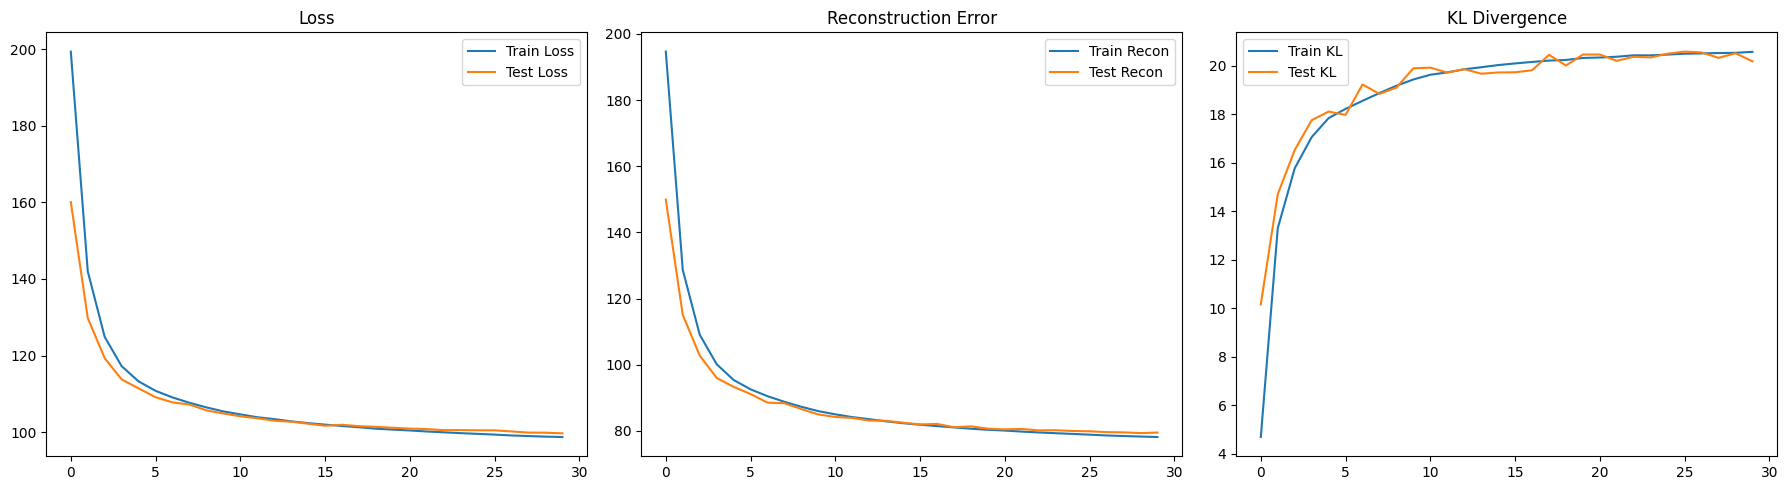

In [6]:
# - curvas de treinamento (3 subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["test_loss"], label="Test Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_recon"], label="Train Recon")
axes[1].plot(history["test_recon"], label="Test Recon")
axes[1].set_title("Reconstruction Error")
axes[1].legend()

axes[2].plot(history["train_kl"], label="Train KL")
axes[2].plot(history["test_kl"], label="Test KL")
axes[2].set_title("KL Divergence")
axes[2].legend()

plt.tight_layout()
# Salve as figuras em output_dir.
plt.savefig(output_dir / "training_curves.png")
plt.show()

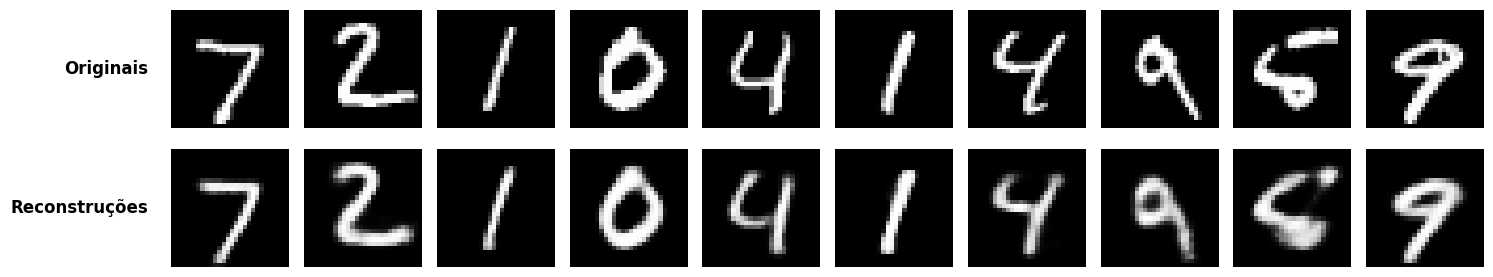

In [7]:
# - reconstruções (2x10)
model.eval()
n_recon = 10

x, _ = next(iter(test_loader))
x = x[:n_recon].to(device) # Pega apenas as primeiras 10 imagens

with torch.no_grad():
    x_hat, _, _ = model(x)

fig, axes = plt.subplots(2, n_recon, figsize=(n_recon * 1.5, 3))

for j in range(n_recon):
    # Imagens Originais
    axes[0, j].imshow(x[j].cpu().squeeze(), cmap="gray")
    axes[0, j].axis("off")

    # Reconstruções
    axes[1, j].imshow(x_hat[j].cpu().squeeze(), cmap="gray")
    axes[1, j].axis("off")

axes[0, 0].text(-0.2, 0.5, "Originais", va='center', ha='right',
                transform=axes[0, 0].transAxes, fontsize=12, fontweight='bold')
axes[1, 0].text(-0.2, 0.5, "Reconstruções", va='center', ha='right',
                transform=axes[1, 0].transAxes, fontsize=12, fontweight='bold')

plt.tight_layout()

# Salve as figuras em output_dir
plt.savefig(output_dir / "reconstructions.png")
plt.show()

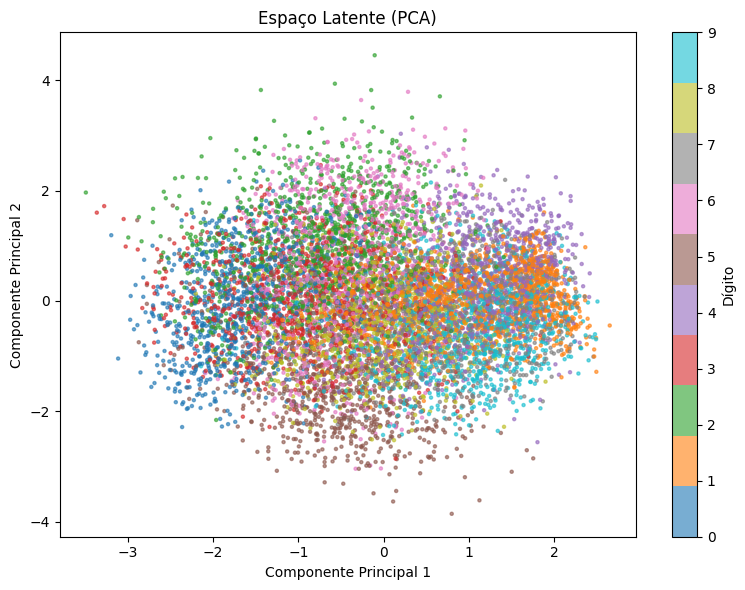

In [9]:
# - espaço latente em 2D (scatter colorido por dígito; PCA se LATENT_DIM > 2)
def plot_pca(model=model, latent_dim=LATENT_DIM, test_loader=test_loader):
    model.eval()

    all_mu = []
    all_labels = []

    for x, labels in test_loader:
        x = x.to(device)
        with torch.no_grad():
            mu, _ = model.encoder(x)
        all_mu.append(mu.cpu())
        all_labels.append(labels)

    all_mu = torch.cat(all_mu).numpy()  # (N, LATENT_DIM)
    all_labels = torch.cat(all_labels).numpy()  # ((N,)

    if latent_dim > 2:
        # 1. Centralizar os dados (subtrair a média de cada dimensão)
        mu_mean = np.mean(all_mu, axis=0)
        mu_centered = all_mu - mu_mean

        # 2. Aplicar o SVD do NumPy
        # full_matrices=False garante que as matrizes tenham dimensões reduzidas (economy size)
        U, S, Vt = np.linalg.svd(mu_centered, full_matrices=False)

        # 3. Projetar os dados nas 2 primeiras componentes principais
        # Vt[:2, :] pega as duas primeiras linhas (os 2 principais eixos de variação)
        mu_2d = mu_centered @ Vt[:2, :].T
    else:
        mu_2d = all_mu

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(mu_2d[:, 0], mu_2d[:, 1], c=all_labels, cmap="tab10", alpha=0.6, s=5)
    plt.colorbar(scatter, ticks=range(10), label="Dígito")

    plt.title("Espaço Latente (PCA)" if latent_dim > 2 else "Espaço Latente")
    plt.xlabel("Componente Principal 1" if latent_dim > 2 else "Dim 1")
    plt.ylabel("Componente Principal 2" if latent_dim > 2 else "Dim 2")

    plt.tight_layout()
    # Salve as figuras em output_dir.
    plt.savefig(output_dir / f"latent_space_pca_{latent_dim}.png")
    plt.show()

plot_pca()

Abaixo fazemos o PCA com `LATENT_DIM=2`, o modelo foi treinado no apêndice B.

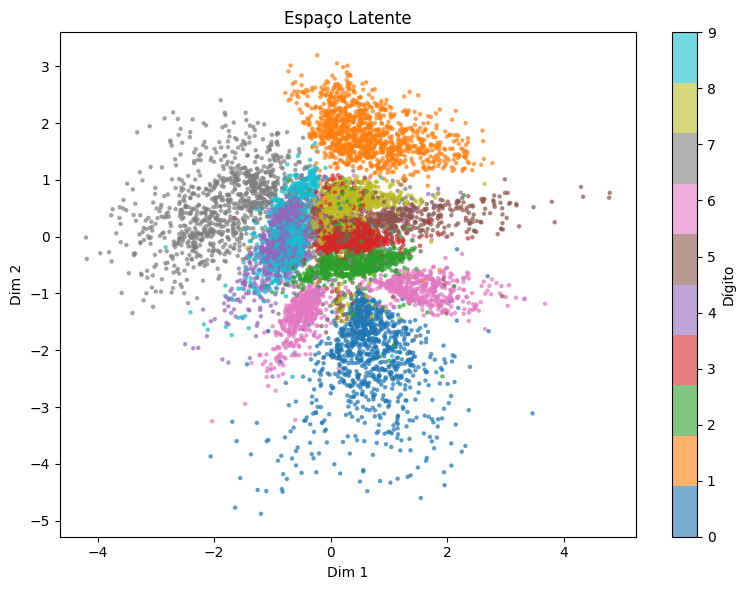

In [16]:
model_ltdim2 = VAE(latent_dim=2).to(device)
model_ltdim2.load_state_dict(torch.load(output_dir / "vae_clean_latent2.pt", map_location=torch.device(device)))

plot_pca(model_ltdim2, latent_dim=2)

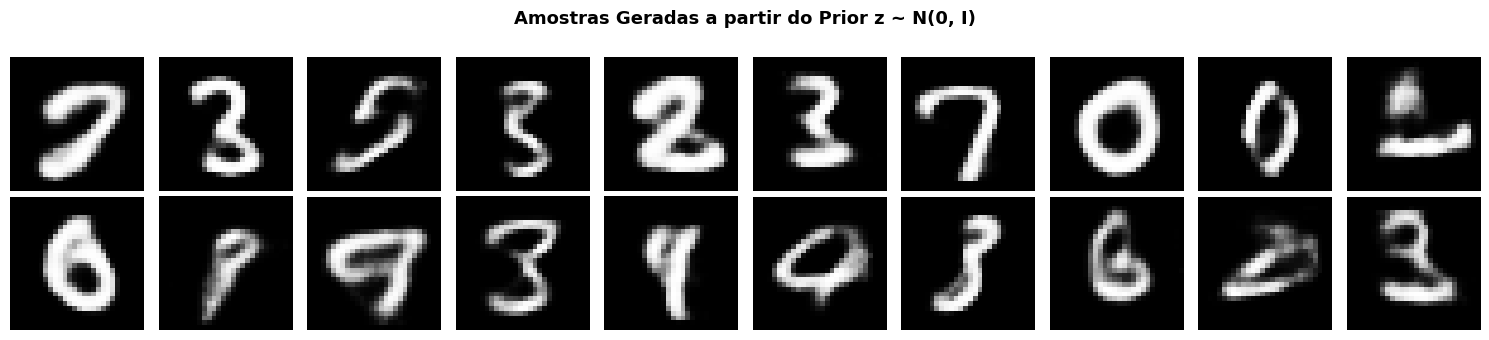

In [17]:
# - amostras do prior (2x10)
model.eval()
n_samples = 20
n_cols = 10  # 2x10

with torch.no_grad():
    # Amostra prior N(0, I)
    z = torch.randn(n_samples, LATENT_DIM).to(device)
    x_hat = model.decoder(z).cpu()

fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 1.5, 3.5))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_hat[i].squeeze(), cmap="gray")
    ax.axis("off")

fig.suptitle("Amostras Geradas a partir do Prior z ~ N(0, I)", fontsize=13, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig(output_dir / "prior_samples.png", bbox_inches='tight')
plt.show()

### Questão 1 — Análise do VAE base

**a)** Compare as curvas de treino e teste. O modelo apresenta underfitting, overfitting, ou está bem ajustado? Justifique com o gap treino/teste e a tendência das curvas.

**b)** Compare reconstruções com amostras do prior. Em qual das duas o VAE produz imagens melhores? Por quê?

**c)** Na projeção 2D do espaço latente (direta se `LATENT_DIM=2`, via PCA caso contrário), as classes ficam separadas? Existem regiões vazias? Conecte a estrutura latente à qualidade das amostras geradas.

*Escreva sua resposta aqui (a, b, c).*

**Respostas**

**a)** Com base nas curvas de treino e teste para a perda e seus termos de reconstrução e divergência KL, podemos dizer que o modelo está bem ajustado. As curvas de treino e teste seguem a mesma tendência nos gráficos ao longo das 30 épocas, de modo que o gap entre as curvas é bem pequeno dentro do número de épocas em que o modelo foi treinado, o que descarta um possível overfitting. Ainda, observamos que os modelos convergem para valores menores e se estabilizam, o que é um indicativo que o modelo aprendeu o que podia sobre a distribuição dos dados.

**b)** O VAE produz amostras melhores nas reconstruções do que nas amostras do prior, com imagens mais nítidas e semelhantes aos z's de quais foram reconstruídas. Isso se deve ao fato de a reconstrução ser condicionada a uma imagem real, mapeada para uma distribuição específica no espaço latente pelo encoder, o que permite que o decoder amostre dessa região específica gerando reconstruções mais fidedignas ao dígito original. Por outro lado, a amostragem a partir da prior (normal padrão) reconstrói amostras aleatórias e, como o espaço latente pode não estar preenchido ou não ser contínuo, o z amostrado pode cair em regiões com baixa densidade ou que o modelo não viu durante o treino, o que gera imagens mais borradas (como obervado na visualização) e que parecem misturas de dígitos.

**c)** Para `LATENT_DIM=2` as classes em geral parecem bem separadas, com algumas sobreposições ou misturas. Já no PCA para `LATENT_DIM=16` as classes estão bem mais sobrepostas, ainda que seja possível observar algumas aglomerações nos extremos, como pontos vermelhos e laranjas, e pontos azuis e roxos, não há uma separação clara dos dígitos no espaço projetado. Para essa distribuição, dentro da distribuição dos pontos, não há espaços vazios evidentes como no espaço de dimensão latente 2. Esse espaço latente aglomerado pode gerar amostrar mais borradas, uma vez que as com as classes sobrepostas o decoder pode gerar imagens que são misturas de dígitos.

## Parte 2 — Marca d'água visível (warmup do auditor)

A versão mais simples do problema: o dono dos dados estampa um **patch branco fixo** num canto das imagens. Esta marca é trivialmente visível, mas serve como referência para entendermos o "limite superior" da detectabilidade.

### 2.1 Definir a marca e o dataset

A marca é um quadrado branco $4 \times 4$ no canto inferior direito (posição `[22:26, 22:26]`), valor $1.0$. Marcamos 20% das imagens de treino, selecionadas aleatoriamente com seed fixa.

**Tarefa 2.1.** Implemente:
- A função `apply_visible_watermark(img)`.
- A classe `VisibleWatermarkedMNIST` que envolve `train_ds` e marca aleatoriamente uma fração das imagens, mantendo `watermarked_indices` para análise posterior.

In [18]:
PATCH_ROW, PATCH_COL = 22, 22
PATCH_SIZE = 4
WM_FRACTION = 0.20


def apply_visible_watermark(img: torch.Tensor) -> torch.Tensor:
    # TODO: clone e estampe um quadrado branco PATCH_SIZE x PATCH_SIZE
    img = img.clone()
    img[:, PATCH_ROW:PATCH_ROW+PATCH_SIZE, PATCH_COL:PATCH_COL+PATCH_SIZE] = 1.0

    return img
    # raise NotImplementedError


class VisibleWatermarkedMNIST(Dataset):
    def __init__(self, base_dataset, fraction=WM_FRACTION, seed=SEED):
        # TODO: amostrar índices a marcar (use np.random.default_rng(seed))
        rng = np.random.default_rng(seed)
        n_samples = len(base_dataset)
        n_watermarked = int(fraction * n_samples)
        self.watermarked_indices = set(rng.choice(n_samples, size=n_watermarked, replace=False))
        self.base_dataset = base_dataset

        # raise NotImplementedError

    def __len__(self):
        return len(self.base_dataset)
        # raise NotImplementedError

    def __getitem__(self, idx):
        # TODO: retornar (img marcada se idx in indices else img, label)
        img, label = self.base_dataset[idx]
        if idx in self.watermarked_indices:
            img = apply_visible_watermark(img)
        return img, label
        # raise NotImplementedError


vis_ds = VisibleWatermarkedMNIST(train_ds)
print(f"Marcadas: {len(vis_ds.watermarked_indices):,} / {len(vis_ds):,}")

Marcadas: 12,000 / 60,000


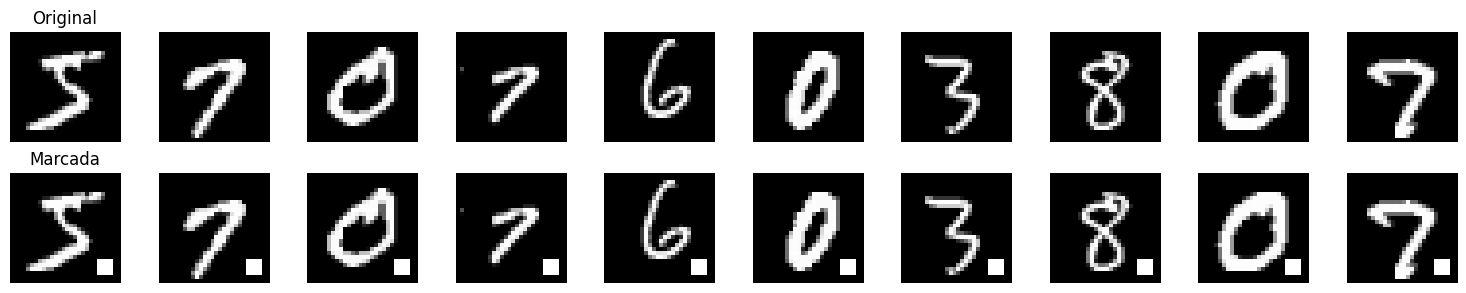

In [19]:
n_display = 10
marked_indices = sorted(list(vis_ds.watermarked_indices))[:n_display]

fig, axes = plt.subplots(2, n_display, figsize=(n_display * 1.5, 3))
for col, idx in enumerate(marked_indices):
    orig_img, _ = train_ds[idx]
    marked_img, _ = vis_ds[idx]

    axes[0, col].imshow(orig_img.squeeze(), cmap="gray")
    axes[0, col].axis("off")
    axes[1, col].imshow(marked_img.squeeze(), cmap="gray")
    axes[1, col].axis("off")

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Marcada")
plt.tight_layout()
plt.savefig(output_dir / "visible_watermark_examples.png")
plt.show()

### 2.2 Treinar o VAE marcado

Treine um novo VAE (`vae_vis`) com **a mesma arquitetura** do `model` (mesma `LATENT_DIM`) mas usando `vis_ds` como dataset de treino. Use 30 épocas, Adam lr=1e-3.

**Dica.** Modularize: escreva uma função `train_vae(loader, latent_dim, epochs, label)` que cria, treina e retorna um novo VAE. Vamos reutilizá-la várias vezes nas próximas partes.

In [20]:
def train_vae(loader, latent_dim, epochs, label, lr=1e-3):
    # TODO: criar VAE(latent_dim), Adam, loop de épocas

    model = VAE(latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        tr = run_epoch(loader, train=True, model=model, optimizer=optimizer)
    # TODO: print resumo a cada N épocas
        if epoch % 5 == 0 or epoch == 1:
            print(f"[{label}] Ep {epoch:3d}/{epochs} | tr loss {tr[0]:.2f}  recon {tr[1]:.2f}  kl {tr[2]:.2f}")

    return model
    # raise NotImplementedError

vis_loader = DataLoader(vis_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
vae_vis = train_vae(vis_loader, LATENT_DIM, epochs=30, label="vis")
torch.save(vae_vis.state_dict(), output_dir / "vae_visible.pt")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[vis] Ep   1/30 | tr loss 207.19  recon 202.72  kl 4.47
[vis] Ep   5/30 | tr loss 116.53  recon 98.83  kl 17.70
[vis] Ep  10/30 | tr loss 108.34  recon 89.19  kl 19.15
[vis] Ep  15/30 | tr loss 104.98  recon 85.04  kl 19.94
[vis] Ep  20/30 | tr loss 103.00  recon 82.59  kl 20.41
[vis] Ep  25/30 | tr loss 101.67  recon 80.99  kl 20.67
[vis] Ep  30/30 | tr loss 100.72  recon 79.85  kl 20.87


### 2.3 Auditoria visual

Use **o mesmo $z$** para gerar amostras de `model` (limpo) e `vae_vis` (com marca). Mostre lado a lado.

**Tarefa 2.3.** Plote 20 amostras de cada modelo (mesmo $z$), em duas linhas — limpo em cima, marcado embaixo.

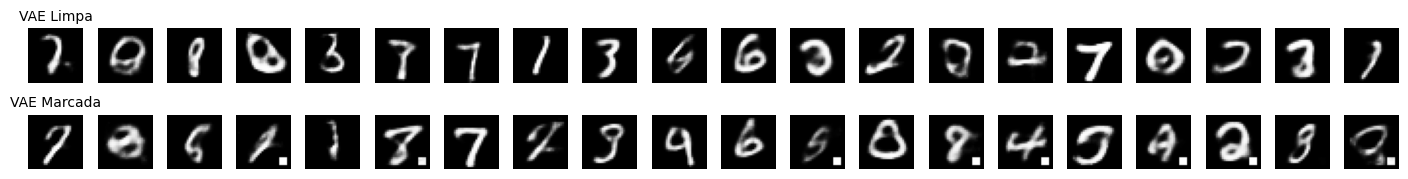

In [38]:
N = 20
# TODO: amostre o mesmo z, decodifique nos 2 modelos, plote lado a lado

model.eval()
vae_vis.eval()

with torch.no_grad():
    z = torch.randn(N, LATENT_DIM).to(device)
    x_hat_clean = model.decoder(z)
    x_hat_vis = vae_vis.decoder(z)

fig, axes = plt.subplots(2, N, figsize=(N * 0.7, 2))
for i in range(N):
    axes[0, i].imshow(x_hat_clean[i].cpu().squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_hat_vis[i].cpu().squeeze(), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_title("VAE Limpa", fontsize=10)
axes[1, 0].set_title("VAE Marcada", fontsize=10)
plt.tight_layout()
plt.savefig(output_dir / "visual_audit_comparison.png", dpi=120)
plt.show()


### 2.4 Auditoria estatística

Quantifique o sinal calculando o **valor médio de pixel** dentro da região do patch:

$$\text{patch\_mean}(x) = \frac{1}{|P|} \sum_{(i,j) \in P} x_{ij}, \quad P = \{(i,j) : 22 \le i, j < 26\}$$

**Tarefa 2.4.** Implemente `patch_mean(imgs)` (tensor `(N, 1, 28, 28)` → tensor `(N,)`). Compute essa métrica para 4 grupos e plote um bar chart comparativo com erro padrão:
1. Imagens limpas do teste (primeiras 1000).
2. Imagens marcadas do treino (primeiros 1000 índices marcados).
3. 1000 amostras do `model` (VAE limpo).
4. 1000 amostras do `vae_vis`.

In [32]:
def patch_mean(imgs: torch.Tensor) -> torch.Tensor:
    # TODO: retornar média de pixels na região do patch, por imagem
    patch = imgs[:, :, PATCH_ROW:PATCH_ROW+PATCH_SIZE, PATCH_COL:PATCH_COL+PATCH_SIZE]
    patch_mean = patch.reshape(imgs.shape[0], -1).mean(dim=1)
    return patch_mean
    # raise NotImplementedError

N_AUDIT = 1000
# TODO: computar patch_mean para os 4 grupos, plotar bar chart, calcular lift

# Imagens limpas do teste (primeiras 1000).
test_clean_means = []
for x, _ in test_loader:
    if len(test_clean_means) >= N_AUDIT:
        break
    x = x.to(device)
    test_clean_means.extend(patch_mean(x).cpu().numpy())
test_clean_means = test_clean_means[:N_AUDIT]

# Imagens marcadas do treino (primeiros 1000 índices marcados).
train_vis_means = []
for x, _ in vis_loader:
    if len(train_vis_means) >= N_AUDIT:
        break
    x = x.to(device)
    train_vis_means.extend(patch_mean(x).cpu().numpy())
train_vis_means = train_vis_means[:N_AUDIT]

# 1000 amostras do `model` (VAE limpo).
model.eval()
with torch.no_grad():
    z = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    gen_clean_imgs = model.decoder(z)
    gen_clean_means = patch_mean(gen_clean_imgs).cpu().numpy()

# 1000 amostras do `vae_vis`.
vae_vis.eval()
with torch.no_grad():
    z = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    gen_vis_imgs = vae_vis.decoder(z)
    gen_vis_means = patch_mean(gen_vis_imgs).cpu().numpy()

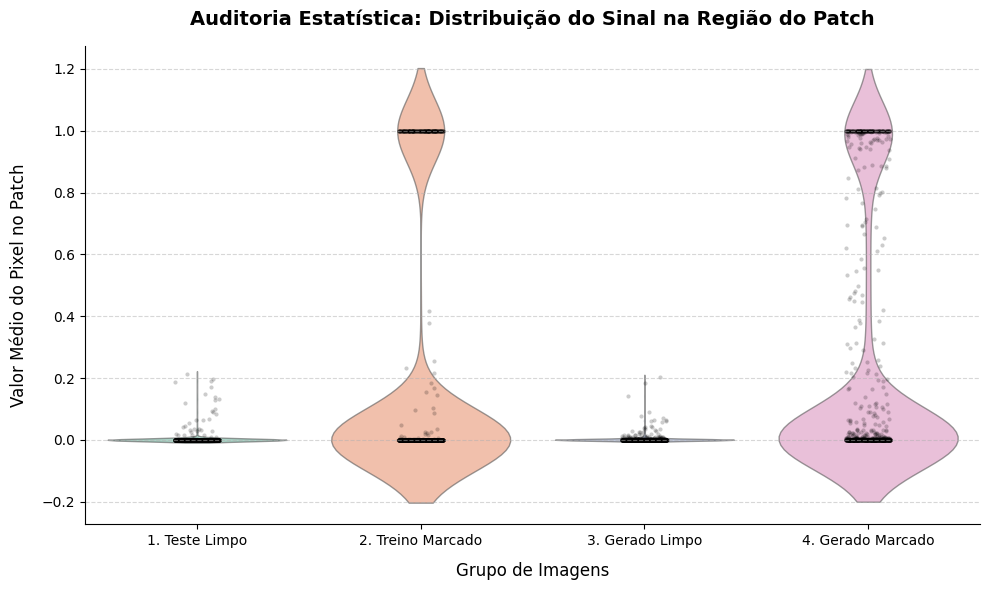

In [33]:
import pandas as pd
import seaborn as sns
df = pd.DataFrame({
    "patch_mean": list(test_clean_means) + list(train_vis_means) + list(gen_clean_means) + list(gen_vis_means),
    "group": (["1. Teste Limpo"] * N_AUDIT +
              ["2. Treino Marcado"] * N_AUDIT +
              ["3. Gerado Limpo"] * N_AUDIT +
              ["4. Gerado Marcado"] * N_AUDIT)
})
plt.figure(figsize=(10, 6))

sns.violinplot(
    x="group",
    y="patch_mean",
    data=df,
    hue="group",
    palette="Set2",
    legend=False,
    inner=None,
    alpha=0.6,
    linewidth=1
)

sns.stripplot(
    x="group",
    y="patch_mean",
    data=df,
    color="black",
    alpha=0.2,
    jitter=True,
    size=3,
    zorder=1
)

plt.title("Auditoria Estatística: Distribuição do Sinal na Região do Patch", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Grupo de Imagens", fontsize=12, labelpad=10)
plt.ylabel("Valor Médio do Pixel no Patch", fontsize=12, labelpad=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()

plt.tight_layout()
plt.savefig(output_dir / "patch_mean_distribution.png", dpi=300)
plt.show()

In [120]:
# --- CALCULAR LIFT ---
# O lift mais interessante para a auditoria é avaliar o quanto o sinal aumentou nas imagens GERADAS

mean_gen_clean = np.mean(gen_clean_means)
mean_gen_vis = np.mean(gen_vis_means)
lift_gerado = (mean_gen_vis - mean_gen_clean) / mean_gen_clean

print(f"Média do Patch (Gerado Limpo): {mean_gen_clean:.4f}")
print(f"Média do Patch (Gerado Marcado): {mean_gen_vis:.4f}")
print(f"Lift Estatístico no Decoder (Sinal da Marca): {lift_gerado:.4f}")

Média do Patch (Gerado Limpo): 0.0022
Média do Patch (Gerado Marcado): 0.2289
Lift Estatístico no Decoder (Sinal da Marca): 103.5810


### Questão 2 — Auditoria da marca visível

**a)** Nas amostras lado a lado (Tarefa 2.3), o patch aparece nas amostras do VAE marcado? Em quantas das 20 é visualmente óbvio?

**b)** Compare `patch_mean` das amostras geradas pelos dois VAEs. Reporte os valores e o lift. O que esse número significa fisicamente?

**c)** Proponha um ataque concreto que o dono do modelo poderia aplicar para destruir este sinal sem prejudicar muito a qualidade visual.

*Escreva suas respostas aqui (a, b, c).*

**Respostas**

**a)** Sim, o patch de marca visível aparece nas amostras geradas pelo VAE marcados. Podemos identificar o patch metade das imagens, sendo mais percepitível em aproximadamente 8 amostras, enquanto nas outras ou o sinal é mais fraco ou não é possível identificá-lo. Isso pode indicar que o modelo, apesar de ter aprendido o sinal do patch, a amostragem no espaço latente nem sempre ativa a região com a mesma intensidade.

**b)** O dados de média dos patches e lift para as amostras geradas pelos dois VAE foram:
- Média do Patch (Gerado Limpo): 0.0022
- Média do Patch (Gerado Marcado): 0.2289
- Lift Estatístico no Decoder (Sinal da Marca): 103.5810

Fisicamente, a média do patch representa a intensidade luminosa da região determinada para o patch. Para o modelo com os dados limpos, a intensidade é baixa, 0.0022, indicando que o modelo original entende que essa região deve ter um fundo preto, ou seja, não deve haver marcação nessa região. Já a média do modelo marcado, 0.2289, apresenta um lift significativo de quase 100%, indicando que os pesos no decoder foram alterados e ele aprendeu um viés espacial de que, independente do dígito a ser reconstruído, a rede ativa os pixels daquela região.

**c)** Com o objetivo de remover a marca de auditoria dos dados, podem ser tomadas abordagens pré e pós processamento. Um ataque mais intuito seria fazer um Crop das imagens geradas, considerando que os MNIST consiste de dígitos centralizados e que a marca foi inserida na borda da imagem. Outra opção é alterar os pesos do modelo por meio de fine-tuning nas últimas camadas do decoder para que o patch deixe de ser ativado, já que o patch foge da distribuição natural dos dados, o modelo desaprenderia esse padrão rápido se aposta a dados não marcados.

## Parte 3 — Marca d'água imperceptível (spread-spectrum)

A marca visível é trivial de remover. Agora projetamos uma marca **invisível ao olho** mas **detectável estatisticamente** — a base dos sistemas de watermarking spread-spectrum.

### 3.1 O padrão secreto

A marca usa uma textura pseudo-aleatória $w \in \mathbb{R}^{28 \times 28}$ conhecida apenas pelo auditor (o dono dos dados). A imagem marcada é:

$$x' = \text{clamp}(x + \varepsilon \cdot w,\, 0, 1)$$

O padrão é gerado a partir de `OWNER_SEED` — apenas o dono dos dados conhece essa chave e pode regenerar $w$ para auditar. O treinador do modelo não precisa conhecê-la.

**Tarefa 3.1.** Execute a célula abaixo — ela já está pronta. O código gera `wm_pattern` a partir de `OWNER_SEED` (usando `torch.Generator` para não perturbar a semente global), **subtrai a média** e normaliza pelo valor absoluto máximo (cada elemento fica em $[-1, 1]$). A visualização usa o mapa de cor `RdBu`. Confirme que a média impressa é $\approx 0$ e que $\max|w| = 1$.

wm_pattern — média: 1.22e-09  max|w|: 1.00


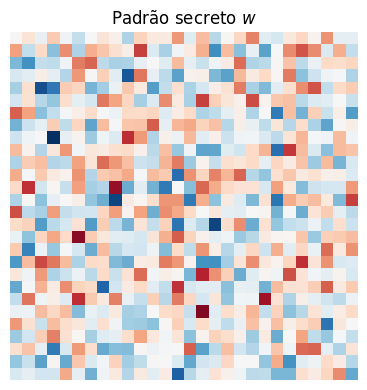

In [42]:
EPSILON        = 0.10
WM_FRACTION_SS = 0.20

# Gerado com OWNER_SEED (isolado do RNG global)
_owner_gen = torch.Generator().manual_seed(OWNER_SEED)
wm_pattern = torch.randn(1, 28, 28, generator=_owner_gen)
wm_pattern = wm_pattern - wm_pattern.mean()
wm_pattern = wm_pattern / wm_pattern.abs().max()

print(f"wm_pattern — média: {wm_pattern.mean().item():.2e}  max|w|: {wm_pattern.abs().max().item():.2f}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(wm_pattern.squeeze(), cmap="RdBu", vmin=-1, vmax=1)
ax.set_title("Padrão secreto $w$"); ax.axis("off")
plt.tight_layout(); plt.savefig(output_dir / "ss_pattern.png", dpi=120); plt.show()

### 3.2 Dataset com marca aditiva

**Tarefa 3.2.** Implemente `SpreadSpectrumMNIST` no mesmo padrão de `VisibleWatermarkedMNIST`, mas aplicando `x' = clamp(x + EPSILON * wm_pattern, 0, 1)`. Visualize um exemplo: original, marcado, e a diferença (amplificada para ser visível).

Marcadas: 12,000 / 60,000


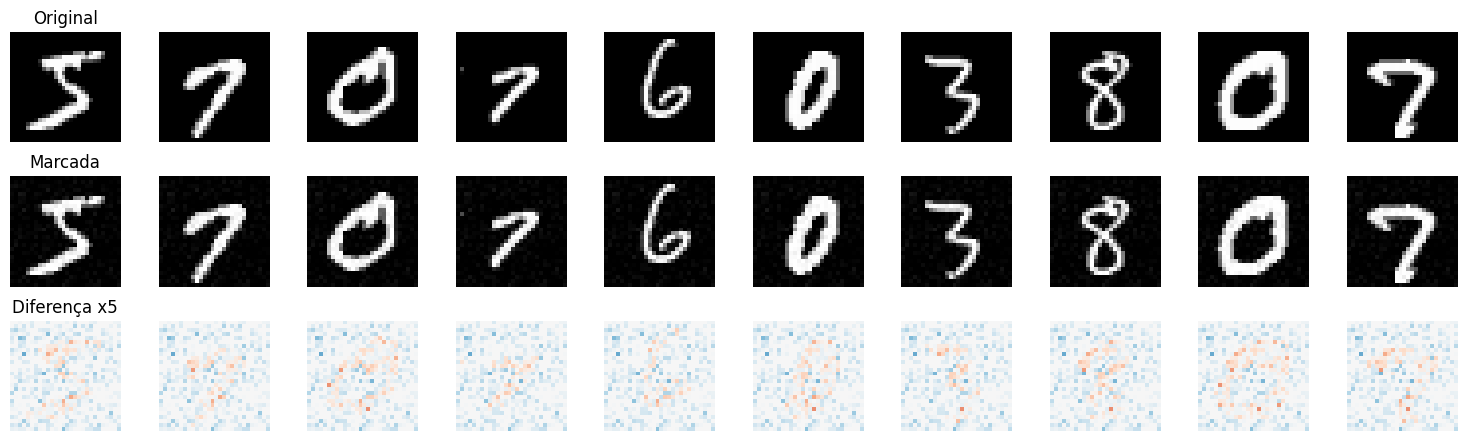

In [43]:
def apply_ss_watermark(img):
    # TODO
    img = img.clone()
    img = img + EPSILON * wm_pattern
    img = img.clamp(0, 1)
    return img
    # raise NotImplementedError

class SpreadSpectrumMNIST(Dataset):
    # TODO
    def __init__(self, base_dataset, fraction=WM_FRACTION_SS, seed=SEED):
        rng = np.random.default_rng(seed)
        n_samples = len(base_dataset)
        n_watermarked = int(fraction * n_samples)
        self.wm_indices = set(rng.choice(n_samples, size=n_watermarked, replace=False))
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        if idx in self.wm_indices:
            img = apply_ss_watermark(img)
        return img, label

ss_ds = SpreadSpectrumMNIST(train_ds, fraction=WM_FRACTION_SS)
print(f"Marcadas: {len(ss_ds.wm_indices):,} / {len(ss_ds):,}")

# TODO: visualizar original vs marcado vs (marcado-original)*5
n_display = 10
marked_indices = sorted(list(ss_ds.wm_indices))[:n_display]
fig, axes = plt.subplots(3, n_display, figsize=(n_display * 1.5, 4.5))
for col, idx in enumerate(marked_indices):
    orig_img, _ = train_ds[idx]
    marked_img, _ = ss_ds[idx]
    diff_img = (marked_img - orig_img) * 5  # amplifica a diferença para visualização

    axes[0, col].imshow(orig_img.squeeze(), cmap="gray")
    axes[0, col].axis("off")
    axes[1, col].imshow(marked_img.squeeze(), cmap="gray")
    axes[1, col].axis("off")
    axes[2, col].imshow(diff_img.squeeze(), cmap="RdBu", vmin=-1, vmax=1)
    axes[2, col].axis("off")
axes[0, 0].set_title("Original")
axes[1, 0].set_title("Marcada")
axes[2, 0].set_title("Diferença x5")
plt.tight_layout()
plt.savefig(output_dir / "ss_watermark_examples.png", dpi=120)
plt.show()


### 3.3 Treinar VAE com a marca imperceptível

Use `train_vae` (definida na Parte 2) para treinar `vae_ss` em `ss_ds`. Mesma arquitetura, 30 épocas.

In [44]:
ss_loader = DataLoader(ss_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
# TODO: treine vae_ss e salve
vae_ss = train_vae(ss_loader, LATENT_DIM, epochs=30, label="ss", lr=1e-3)
torch.save(vae_ss.state_dict(), output_dir / "vae_ss.pt")

# raise NotImplementedError

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[ss] Ep   1/30 | tr loss 206.76  recon 202.42  kl 4.33
[ss] Ep   5/30 | tr loss 123.86  recon 107.17  kl 16.70
[ss] Ep  10/30 | tr loss 114.60  recon 95.42  kl 19.18
[ss] Ep  15/30 | tr loss 111.46  recon 91.67  kl 19.79
[ss] Ep  20/30 | tr loss 109.74  recon 89.66  kl 20.09
[ss] Ep  25/30 | tr loss 108.56  recon 88.29  kl 20.27
[ss] Ep  30/30 | tr loss 107.78  recon 87.36  kl 20.42


### 3.4 Detector ingênuo de correlação (e por que ele tem um problema)

O detector natural é a **correlação** entre uma imagem gerada e o padrão secreto:

$$\text{score}(x) = \langle x,\, w \rangle = \sum_{i,j} x_{ij} \, w_{ij}$$

**Tarefa 3.4a.** Implemente `corr_score(imgs, pattern)` e calcule os scores para 2000 amostras do `model` (limpo) e 2000 do `vae_ss` (marcado). Plote ambos como histogramas sobrepostos.

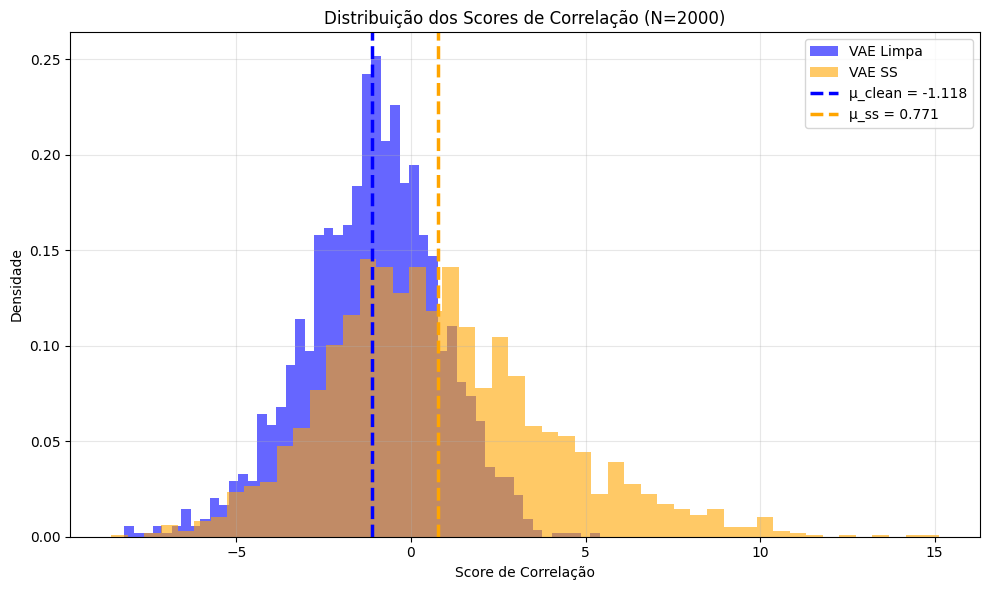

In [54]:
def corr_score(imgs, pattern):
    # TODO: produto interno por imagem
    imgs_flat = imgs.reshape(imgs.shape[0], -1)  # (N, 784)
    pattern_flat = pattern.reshape(-1)  # (784,)
    scores = torch.matmul(imgs_flat, pattern_flat)  # (N,)
    return scores
    # raise NotImplementedError

N_AUDIT = 2000
model.eval(); vae_ss.eval()
# TODO: gerar amostras com o mesmo z, computar scores, plotar histogramas
with torch.no_grad():
    z = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    x_hat_clean = model.decoder(z)
    x_hat_ss = vae_ss.decoder(z)

scores_clean = corr_score(x_hat_clean, wm_pattern.to(device)).cpu().numpy()
scores_ss = corr_score(x_hat_ss, wm_pattern.to(device)).cpu().numpy()

# Plote os histogramas
plt.figure(figsize=(10, 6))
plt.hist(scores_clean, bins=50, alpha=0.6, label="VAE Limpa", color="blue", density=True)
plt.hist(scores_ss, bins=50, alpha=0.6, label="VAE SS", color="orange", density=True)
plt.axvline(scores_clean.mean(), color="blue", linestyle="--", linewidth=2.5, label=f"μ_clean = {scores_clean.mean():.3f}")
plt.axvline(scores_ss.mean(), color="orange", linestyle="--", linewidth=2.5, label=f"μ_ss = {scores_ss.mean():.3f}")
plt.title(f"Distribuição dos Scores de Correlação (N={N_AUDIT})")
plt.xlabel("Score de Correlação")
plt.ylabel("Densidade")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "correlation_scores.png", dpi=120)

plt.show()
# raise NotImplementedError

### 3.5 Diagnóstico: por que o VAE limpo não está centrado em zero?

Você provavelmente observou que o histograma do **VAE limpo** não está centrado em $0$. Isso parece contraditório: o modelo nunca viu $w$, então a correlação não deveria ser ruído puro?

**Tarefa 3.5.** Explique matematicamente por que $\mathbb{E}[\langle x_{\text{clean}}, w \rangle] \ne 0$ em geral. Calcule numericamente o valor que causa esse desvio e mostre que ele coincide com a média empírica do histograma.

O score de uma imagem gerada é o produto interno $\langle x_{\text{clean}}, w \rangle$. Pela linearidade da esperança (valor esperado) e como o padrão $w$ é fixo, temos:

$$\mathbb{E}[\langle x_{\text{clean}}, w \rangle] = \langle \mathbb{E}[x_{\text{clean}}], w \rangle$$

Como um bom VAE aprende a distribuição dos dados de treino, a média das imagens geradas tende a ser a própria imagem média do dataset: $\mathbb{E}[x_{\text{clean}}] \approx \mu_{\text{mnist}}$.

Assim, a média da distribuição limpa não é zero, mas sim:

$$\mathbb{E}[\langle x_{\text{clean}}, w \rangle] \approx \langle \mu_{\text{mnist}}, w \rangle$$

Como os pixels do MNIST não são negativos (há dígitos brancos no fundo preto), a imagem média $\mu_{\text{mnist}}$ não é nula. Seu produto com o padrão $w$ resulta em um valor constante não-zero, deslocando o histograma.

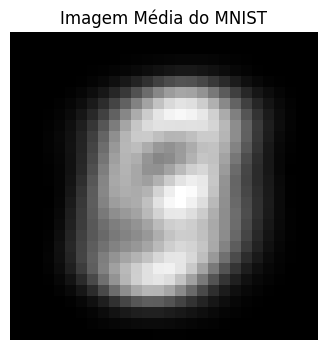


Score do mu_mnist: -1.0688

Score do VAE limpo: -1.1183
Diferença: 0.0495


In [64]:
# TODO: compute a imagem média do MNIST limpo (mu_mnist) e seu produto interno com wm_pattern
mu_mnist = torch.stack([train_ds[i][0] for i in range(len(train_ds))], dim=0).mean(dim=0)

plt.figure(figsize=(4, 4))
plt.imshow(mu_mnist.cpu().squeeze().numpy(), cmap='gray')
plt.title("Imagem Média do MNIST")
plt.axis('off')
plt.show()

score_mu_mnist = torch.matmul(mu_mnist.flatten(), wm_pattern.flatten()).item()

print(f"\nScore do mu_mnist: {score_mu_mnist:.4f}")

# Compare com a média do histograma do VAE limpo da seção anterior — devem ser parecidos.
print(f"\nScore do VAE limpo: {scores_clean.mean():.4f}")
print(f"Diferença: {abs(scores_clean.mean() - score_mu_mnist):.4f}")

# raise NotImplementedError

### 3.6 Detector centralizado

Para o detector ser interpretável (histograma centrado em zero sob $H_0$), subtraia o offset $\langle \mu_{\text{MNIST}}, w \rangle$ centralizando as imagens antes de calcular a correlação:

$$\text{corr\_centered}(x) = \langle x - \mu_{\text{MNIST}},\, w \rangle$$

**Tarefa 3.6.** Implemente `corr_score_centered(imgs, pattern, mean_img)` e refaça o histograma. O histograma do VAE limpo deve agora aparecer próximo de zero.

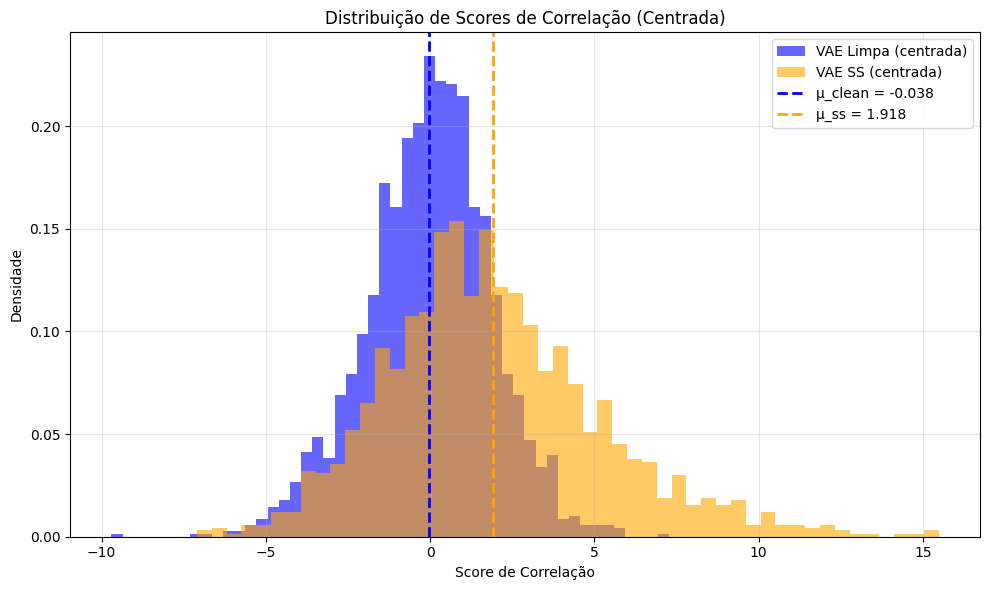

Média VAE limpa (centrada): -0.037725
Média VAE SS (centrada): 1.918128
Std VAE limpa: 1.914394
Std VAE SS: 3.307981


In [66]:
def corr_score_centered(imgs, pattern, mean_img):
    # TODO:
    # <x - mean_img, pattern>
    imgs_centered = imgs - mean_img
    imgs_flat = imgs_centered.reshape(imgs_centered.shape[0], -1)  # (N, 784)
    pattern_flat = pattern.reshape(-1)  # (784,)
    scores = torch.matmul(imgs_flat, pattern_flat)  # (N,)
    return scores

# TODO: recomputar os scores e replotar o histograma centrado
mu_mnist_device = mu_mnist.to(device)
with torch.no_grad():
    z_clean = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    z_ss = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    x_hat_clean = model.decoder(z_clean)
    x_hat_ss = vae_ss.decoder(z_ss)

scores_clean_centered = corr_score_centered(x_hat_clean, wm_pattern.to(device), mu_mnist_device).cpu().numpy()
scores_ss_centered = corr_score_centered(x_hat_ss, wm_pattern.to(device), mu_mnist_device).cpu().numpy()

plt.figure(figsize=(10, 6))
plt.hist(scores_clean_centered, bins=50, alpha=0.6, label="VAE Limpa (centrada)", color="blue", density=True)
plt.hist(scores_ss_centered, bins=50, alpha=0.6, label="VAE SS (centrada)", color="orange", density=True)
plt.axvline(scores_clean_centered.mean(), color="blue", linestyle="--", linewidth=2, label=f"μ_clean = {scores_clean_centered.mean():.3f}")
plt.axvline(scores_ss_centered.mean(), color="orange", linestyle="--", linewidth=2, label=f"μ_ss = {scores_ss_centered.mean():.3f}")
plt.title("Distribuição de Scores de Correlação (Centrada)")
plt.xlabel("Score de Correlação")
plt.ylabel("Densidade")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "correlation_scores_centered.png", dpi=120)
plt.show()

print(f"Média VAE limpa (centrada): {scores_clean_centered.mean():.6f}")
print(f"Média VAE SS (centrada): {scores_ss_centered.mean():.6f}")
print(f"Std VAE limpa: {scores_clean_centered.std():.6f}")
print(f"Std VAE SS: {scores_ss_centered.std():.6f}")


### 3.7 Teste de hipótese

Com os scores centralizados, formalizamos a auditoria como um **teste de duas amostras**. O auditor gera $N$ amostras independentes do modelo suspeito e $N$ amostras independentes de um modelo de referência limpo, e testa se as médias diferem:

$$t = \frac{\bar{s}_{\text{ss}} - \bar{s}_{\text{clean}}}{\sqrt{(\hat{\sigma}_{\text{ss}}^2 + \hat{\sigma}_{\text{clean}}^2)/N}}$$

**Tarefa 3.7.** Gere 2000 amostras independentes de cada modelo (use `torch.randn` separado para cada). Compute `sc_clean`, `sc_ss` e o t-estatístico acima. Plote os histogramas e imprima o t-estatístico.

--------------------------------------------------
Média Clean:     -0.1808
Média SS:        1.8339
Estatística t:   23.8704
--------------------------------------------------


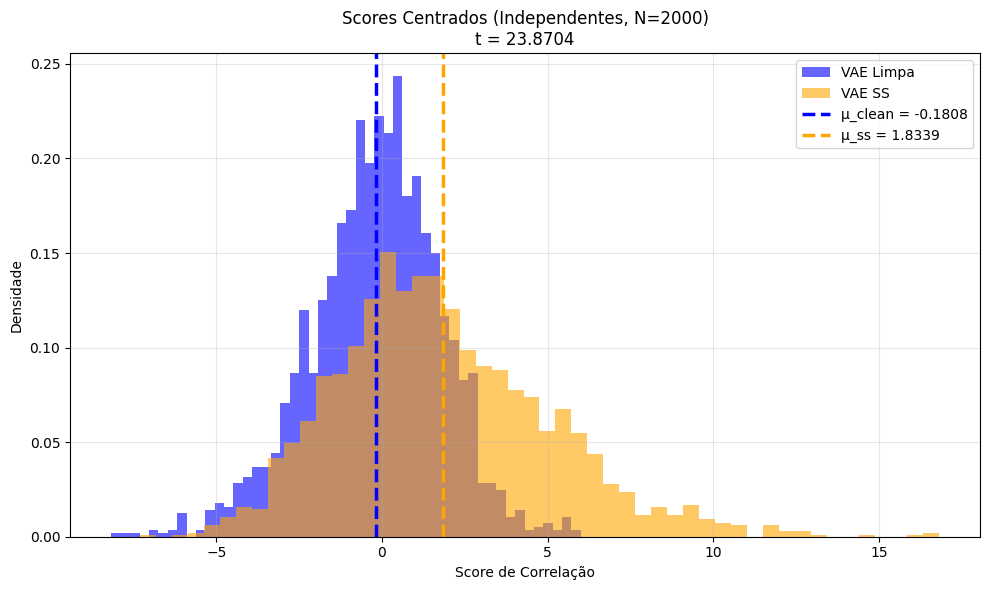

In [73]:
N_AUDIT = 2000

# TODO: gerar N_AUDIT amostras INDEPENDENTES de cada modelo
# (dois torch.randn separados — não compartilhe z entre os modelos)
model.eval(); vae_ss.eval()
with torch.no_grad():
    z_clean_ind = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    z_ss_ind = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    x_hat_clean_ind = model.decoder(z_clean_ind)
    x_hat_ss_ind = vae_ss.decoder(z_ss_ind)

# Compute sc_clean e sc_ss usando corr_score_centered
sc_clean = corr_score_centered(x_hat_clean_ind, wm_pattern.to(device), mu_mnist_device).cpu().numpy()
sc_ss = corr_score_centered(x_hat_ss_ind, wm_pattern.to(device), mu_mnist_device).cpu().numpy()

# Compute o t-estatístico de duas amostras
mean_clean = sc_clean.mean()
mean_ss = sc_ss.mean()
var_clean = sc_clean.var(ddof=1)
var_ss = sc_ss.var(ddof=1)
t_stat = (mean_ss - mean_clean) / np.sqrt((var_clean + var_ss) / N_AUDIT)

print("-" * 50)
print(f"Média Clean:     {mean_clean:.4f}")
print(f"Média SS:        {mean_ss:.4f}")
print(f"Estatística t:   {t_stat:.4f}")
print("-" * 50)

# Plote os histogramas
plt.figure(figsize=(10, 6))
plt.hist(sc_clean, bins=50, alpha=0.6, label="VAE Limpa", color="blue", density=True)
plt.hist(sc_ss, bins=50, alpha=0.6, label="VAE SS", color="orange", density=True)
plt.axvline(mean_clean, color="blue", linestyle="--", linewidth=2.5, label=f"μ_clean = {mean_clean:.4f}")
plt.axvline(mean_ss, color="orange", linestyle="--", linewidth=2.5, label=f"μ_ss = {mean_ss:.4f}")
plt.title(f"Scores Centrados (Independentes, N={N_AUDIT})\nt = {t_stat:.4f}")
plt.xlabel("Score de Correlação")
plt.ylabel("Densidade")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "hypothesis_test_independent.png", dpi=120)
plt.show()


### Questão 3 — Análise do detector spread-spectrum

**a)** Descreva o histograma ingênuo (Tarefa 3.4): os dois grupos estão centrados onde você esperaria? Você conseguiria detectar a marca sem ajustes?

**b)** Explique matematicamente por que o VAE limpo não está centrado em zero. Reporte o valor de $\langle \mu_\text{MNIST}, w \rangle$ que você calculou e compare com a média observada no histograma.

**c)** Após os fixes (Tarefa 3.6), os histogramas estão centrados e separados? Reporte o t-estatístico e interprete: a marca é detectável com N=2000?

*Escreva suas respostas aqui (a, b, c).*

**Respostas**

**a)** Considerando o histograma ingênuo e a expectativa das médias em um detector spread-spectrum padrão, os grupos não estão centrados onde seria esperado. A expectiva seria que as imagens limpas obtessem um score de correlação zero, enquanto as imagens marcadas apresentem um score positivo. No entanto, no histograma da Tarefa 3.4, a média do dados limpos está deslocada para a esquerda (score negativo). Com esses deslocamento e a sobreposição entre as duas distribuições, seria difícil detectar a marca sem ajustes prévios, já que valores de limiar resultariam em FP (imagens limpas ditas marcadas) e FN (imagens marcadas ditas como limpas).

**b)** Matematicamente, o VAE limpo não está centrado em zero pois o score do detector ingênuo é calculado pelo produto interno da imagem e o vetor de marca $w$. Como o dataset é composto por imagens com fundo escuro e traços claros específicos para cada dígito, a média dos pixels não é igual para todas as imagens ($\mu_{MNIST} \neq 0$). Logo, o valor esperado do score para uma imagem limpa é dado por $\mathbb{E}[\langle X_{\text{clean}}, w \rangle] = \langle \mu_{\text{MNIST}}, w \rangle$. Como a marca é gerada aleatoriamente e fixada, atuando como uma projeção. Desse modo, o cálculo teórico de $\langle \mu_{\text{MNIST}}, w \rangle$ deve corresponder à média observada no histograma ingênuo, explicando por que a distribuição limpa foi deslocada da forma observada.

**c)** Após as correções (Tarefa 3.6), os histogramas apresentam-se adequadamente separados e centrados, com a distribuição das imagens limpas posicionada muito próxima à origem ($\mu_{\text{clean}} = -0.1808$) e a das imagens com marca d'água visivelmente deslocada para a direita ($\mu_{\text{ss}} = 1.8339$). A avaliação dessa separação com N=2000 amostras resultou em um t-estatístico expressivo de **23.8704**, o que demonstra uma diferença estatística robusta entre os dois grupos. Consequentemente, ao corrigir o viés da linha de base, a distinção entre o ruído e o sinal torna-se estatisticamente evidente, fazendo com que a marca d'água seja detectável de forma confiável.

## Parte 4 — Estudo controlado: quanto sinal e quantos dados?

A Parte 3 usou uma única configuração ($\varepsilon = 0.10$, fração $= 0.20$). Aqui mapeamos sistematicamente como a detectabilidade depende dessas escolhas.

> *Dica: você pode usar menos épocas por VAE na varredura para reduzir o tempo de execução. Se fizer isso, retreine o VAE limpo com o mesmo número de épocas antes da varredura — a comparação só é justa quando todos os modelos treinam sob as mesmas condições.*

### 4.1 Fábrica de datasets

**Tarefa 4.1.** Implemente `make_ss_dataset(eps, fraction)` que cria um dataset com `fraction` das imagens marcadas com amplitude `eps`.

In [ ]:
# TODO: escolha pelo menos 2 valores para cada parâmetro
EPSILON_VALUES  = [0.05, 0.10, 0.15, 0.20]   # ex: [0.05, 0.10]
FRACTION_VALUES = [0.05, 0.10, 0.20]   # ex: [0.10, 0.20]
N_AUDIT         = 2000    # fixo
EPOCHS_ABLATION = 15     # pode ser menor que EPOCHS — veja a dica acima

def make_ss_dataset(eps, fraction, seed=SEED):
    # TODO: retornar um Dataset que aplica a marca em `fraction` das imagens de treino
    # com amplitude `eps`
    class SpreadSpectrumMNISTAblation(Dataset):
        def __init__(self, base_dataset, epsilon, frac, seed_val):
            rng = np.random.default_rng(seed_val)
            n_samples = len(base_dataset)
            n_watermarked = int(frac * n_samples)
            self.wm_indices = set(rng.choice(n_samples, size=n_watermarked, replace=False))
            self.base_dataset = base_dataset
            self.epsilon = epsilon

        def __len__(self):
            return len(self.base_dataset)

        def __getitem__(self, idx):
            img, label = self.base_dataset[idx]
            if idx in self.wm_indices:
                img = img.clone()
                img = img + self.epsilon * wm_pattern
                img = img.clamp(0, 1)
            return img, label

    return SpreadSpectrumMNISTAblation(train_ds, eps, fraction, seed)

# Retreina o VAE limpo com EPOCHS_ABLATION para comparação justa
# TODO: chamar train_vae com train_loader, LATENT_DIM, EPOCHS_ABLATION
print("Retreinando VAE limpo com EPOCHS_ABLATION para ablação...")
model_ab = train_vae(train_loader, LATENT_DIM, epochs=EPOCHS_ABLATION, label="clean_ab")
print("✓ Modelo de referência retreinado.")

Retreinando VAE limpo com EPOCHS_ABLATION para ablação...
[clean_ab] Ep   1/15 | tr loss 197.64  recon 192.96  kl 4.68
[clean_ab] Ep   5/15 | tr loss 113.77  recon 96.87  kl 16.90
[clean_ab] Ep  10/15 | tr loss 106.84  recon 88.93  kl 17.91
[clean_ab] Ep  15/15 | tr loss 103.50  recon 84.64  kl 18.86
✓ Modelo de referência retreinado.


### 4.2 Varredura

**Tarefa 4.2.** Execute a varredura sobre a grade `EPSILON_VALUES × FRACTION_VALUES` (o `model_ab` já foi retreinado na 4.1 acima):
1. Para cada (ε, fração), treine um VAE marcado com `EPOCHS_ABLATION` épocas.
2. Para cada par, gere `N_AUDIT` amostras **independentes** de `model_ab` e do VAE marcado.
3. Compute o t-estatístico de duas amostras (mesma fórmula da Parte 3.7) e registre o sinal médio.

Guarde os resultados numa lista de dicts com chaves `eps`, `frac`, `signal`, `t`.

In [ ]:
# TODO: implementar a varredura
# Para cada (eps, frac) em EPSILON_VALUES × FRACTION_VALUES:
results = []
for eps in EPSILON_VALUES:
    for frac in FRACTION_VALUES:
#   1. Crie o dataset com make_ss_dataset(eps, frac)
        ss_ds_ab = make_ss_dataset(eps, frac)
        ss_loader_ab = DataLoader(ss_ds_ab, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

#   2. Treine um VAE com EPOCHS_ABLATION épocas
        print(f"\nTreinando VAE com EPSILON={eps} e FRACTION={frac} ({EPOCHS_ABLATION} épocas)...")
        vae_ab = train_vae(ss_loader_ab, LATENT_DIM, epochs=EPOCHS_ABLATION, label=f"ss_eps{eps}_frac{frac}")

#   3. Gere N_AUDIT amostras INDEPENDENTES de model_ab e do VAE marcado
        with torch.no_grad():
            z_ab = torch.randn(N_AUDIT, LATENT_DIM).to(device)
            z_marked = torch.randn(N_AUDIT, LATENT_DIM).to(device)
            x_hat_ab = model_ab.decoder(z_ab)
            x_hat_marked = vae_ab.decoder(z_marked)

#   4. Compute o t-estatístico de duas amostras e o sinal médio
        sc_ab = corr_score_centered(x_hat_ab, wm_pattern.to(device), mu_mnist_device).cpu().numpy()
        sc_marked = corr_score_centered(x_hat_marked, wm_pattern.to(device), mu_mnist_device).cpu().numpy()

        mean_ab = sc_ab.mean()
        mean_marked = sc_marked.mean()
        var_ab = sc_ab.var(ddof=1)
        var_marked = sc_marked.var(ddof=1)
        t_stat_ab = (mean_marked - mean_ab) / np.sqrt((var_ab + var_marked) / N_AUDIT)

#   5. Guarde em results como dict {"eps": ..., "frac": ..., "signal": ..., "t": ...}
        results.append({"eps": eps, "frac": frac, "signal": mean_marked, "t": t_stat_ab})

# raise NotImplementedError


Treinando VAE com EPSILON=0.05 e FRACTION=0.05 (15 épocas)...
[ss_eps0.05_frac0.05] Ep   1/15 | tr loss 198.73  recon 193.99  kl 4.73
[ss_eps0.05_frac0.05] Ep   5/15 | tr loss 115.89  recon 98.57  kl 17.32
[ss_eps0.05_frac0.05] Ep  10/15 | tr loss 107.50  recon 88.26  kl 19.24
[ss_eps0.05_frac0.05] Ep  15/15 | tr loss 104.28  recon 84.40  kl 19.88

Treinando VAE com EPSILON=0.05 e FRACTION=0.1 (15 épocas)...
[ss_eps0.05_frac0.1] Ep   1/15 | tr loss 202.06  recon 197.68  kl 4.38
[ss_eps0.05_frac0.1] Ep   5/15 | tr loss 117.11  recon 100.41  kl 16.70
[ss_eps0.05_frac0.1] Ep  10/15 | tr loss 109.82  recon 92.01  kl 17.81
[ss_eps0.05_frac0.1] Ep  15/15 | tr loss 106.92  recon 88.66  kl 18.26

Treinando VAE com EPSILON=0.05 e FRACTION=0.2 (15 épocas)...
[ss_eps0.05_frac0.2] Ep   1/15 | tr loss 202.81  recon 198.46  kl 4.34
[ss_eps0.05_frac0.2] Ep   5/15 | tr loss 119.59  recon 102.95  kl 16.65
[ss_eps0.05_frac0.2] Ep  10/15 | tr loss 112.12  recon 94.29  kl 17.84
[ss_eps0.05_frac0.2] Ep  1

### 4.3 Visualização dos resultados

**Tarefa 4.3.** Plote dois heatmaps com eixos $(\varepsilon, \text{fração})$:
1. Sinal médio $\bar{d} = \bar{s}_{\text{wm}} - \bar{s}_{\text{clean}}$.
2. T-estatístico (duas amostras independentes).

Anote o valor em cada célula do heatmap.

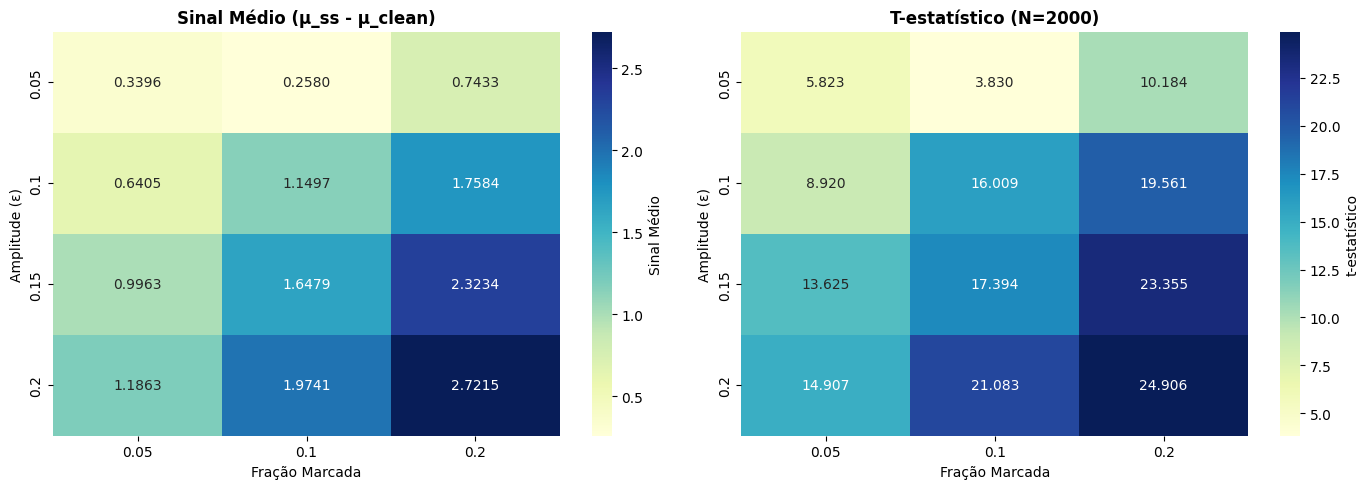


Resultados da ablação:
 eps  frac   signal         t
0.05  0.05 0.339644  5.822703
0.05  0.10 0.258024  3.830226
0.05  0.20 0.743268 10.183538
0.10  0.05 0.640462  8.919937
0.10  0.10 1.149738 16.009153
0.10  0.20 1.758353 19.560595
0.15  0.05 0.996294 13.624533
0.15  0.10 1.647858 17.394363
0.15  0.20 2.323428 23.355284
0.20  0.05 1.186256 14.907201
0.20  0.10 1.974117 21.082661
0.20  0.20 2.721491 24.906244


In [ ]:
# TODO: heatmap signal_grid, heatmap t_grid
df_results = pd.DataFrame(results)
signal_grid = df_results.pivot(columns="frac", index="eps", values="signal")
t_grid = df_results.pivot(columns="frac", index="eps", values="t")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de sinal
sns.heatmap(signal_grid, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[0], cbar_kws={"label": "Sinal Médio"})
axes[0].set_title("Sinal Médio (μ_ss - μ_clean)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Fração Marcada")
axes[0].set_ylabel("Amplitude (ε)")

# Heatmap de t-estatístico
sns.heatmap(t_grid, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[1], cbar_kws={"label": "t-estatístico"})
axes[1].set_title("T-estatístico (N=2000)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Fração Marcada")
axes[1].set_ylabel("Amplitude (ε)")

plt.tight_layout()
plt.savefig(output_dir / "ablation_heatmaps.png", dpi=120)
plt.show()

print("\nResultados da ablação:")
print(df_results.to_string(index=False))

### Questão 4 — Análise dos resultados da ablação

**a)** Olhando o heatmap de sinal médio, como $\bar{d}$ cresce com $\varepsilon$ e com a fração? O crescimento é aproximadamente linear em cada eixo? Use 2–3 pares de células para justificar com números.

**b)** No heatmap de t-estatístico, qual é a menor combinação $(\varepsilon, \text{fração})$ que atinge $|t| > 3$? Existem células onde a marca não foi detectável mesmo com N=2000?

**c)** Com base nos seus resultados, qual é o par $(\varepsilon, \text{fração})$ mínimo que você recomendaria para um cenário de auditoria real? Justifique considerando tanto a detectabilidade quanto o custo de marcar os dados.

*Escreva suas respostas aqui (a, b, c).*

**Respostas**

**a)** O sinal médio $\bar{d}$ apresenta uma tendência geral de crescimento quando a amplitude $\varepsilon$ e a fração marcada aumentam, no entanto esse crescimento não é estritamente linear, apresentando algumas oscilações.
- Se fixarmos a fração, digamos em $0.20$, ao dobrar a amplitude de $\varepsilon = 0.10$ para $\varepsilon = 0.20$, podemos observar que o sinal cresce, com um aumento de aproximadamente $1.5 \times$.
- Se fixarmos a amplitude, digamos em $\varepsilon =0.15$, ao dobrar a fração marcada de $0.10$ para $0.20$, o sinal cresce, com um aumento de aproximadamente $1.4 \times$.
- Como dito, esse crescimento não é estritamente linear, exibindo algumas oscilações. Podemos observar esse comportamento para os valores mais baixos, por exemplo, com uma amplitude fixada de $\varepsilon=0.05$, dobrar a fração de $0.05$ para $0.10$ resulta em uma queda no sinal médio.

**b)** A menor combinação de parâmetros, $\varepsilon = 0.05$ e fração $= 0.05$, já atinge um t-estatístico de **5.823**, ultrapassando o limiar de $|t| > 3$. O menor valor encontrado em todo a varredura ocorre na célula de $\varepsilon = 0.05$ com fração $= 0.10$ ($t = 3.830$), mas ainda assim é estatisticamente significante. Desse modo, para o tamanho de amostra $N=2000$, não existem células indetectáveis dentre as combinações testadas.

**c)** Considerando a detectabilidade e o custo de marcar os dados, o par $(\varepsilon, \text{fração})$ mínimo recomendável para uma situação de auditorial real seria $(0.05, 0.05)$. Esse par já fornece evidência estatística para a detectabilidade da marca, não sendo necessário marcar grande parte do conjunto de dados, nem degradar muito os dados com grandes amplitudes.

## Parte 5 — Extensões (Bônus)

Esta parte é **opcional**. **Escolha *uma* das duas questões abaixo** e implemente-a. Isso rende +10% na nota final.

### 5.1 — Robustez da marca a um ataque defensivo

Suponha que o dono do modelo gerador, sabendo que pode existir uma marca spread-spectrum, aplica um filtro às amostras antes de liberá-las. Implemente o ataque mais simples possível: **blur Gaussiano** nas amostras do `vae_ss` antes de calcular o score.

Rode o detector centralizado da Parte 3 em três condições: (i) sem ataque, (ii) blur com $\sigma=0.5$, (iii) blur com $\sigma=1.0$. Use $\varepsilon=0.10$, frac $=0.20$, $N=2000$.

Reporte os três valores de $t$ numa tabela e responda: o sinal sobrevive? A partir de que $\sigma$ a marca se torna indetectável ($|t| < 3$)?

----------------------------------------
ROBUSTEZ A BLUR GAUSSIANO
----------------------------------------
 sigma    t_stat  detectável
   0.0 23.372643        True
   0.5 18.234272        True
   1.0  9.319047        True 



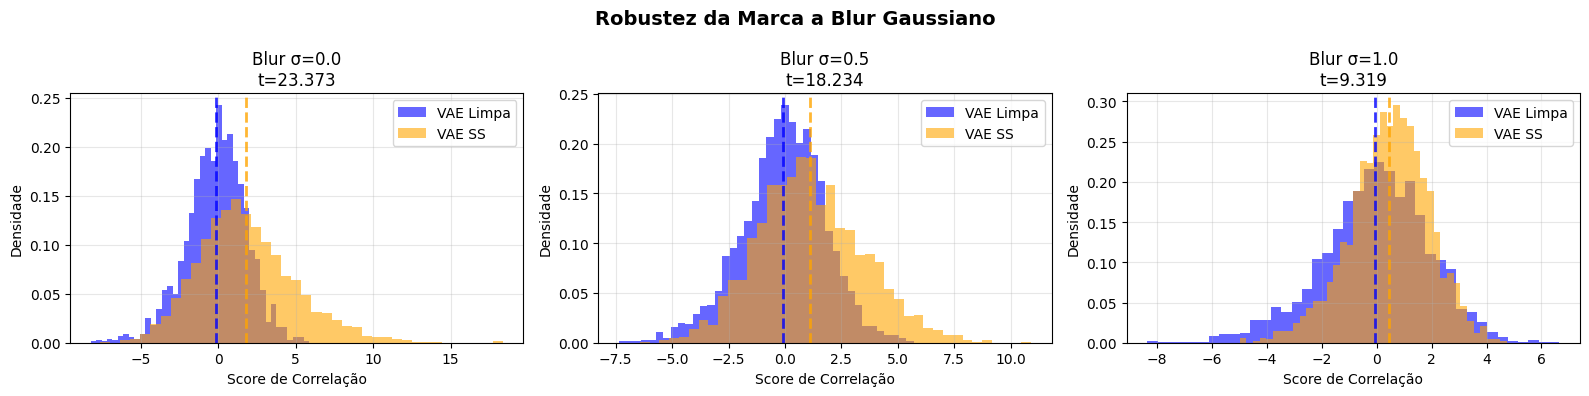

In [88]:
# Ataque defensivo: blur Gaussiano
# Rode o detector centralizado da Parte 3 em três condições:
# (i) sem ataque, (ii) blur com σ=0.5, (iii) blur com σ=1.0

import torch.nn.functional as F
from torchvision.transforms import GaussianBlur

# ε=0.10, frac=0.20, N=2000 (Parte 3)
N_AUDIT_ROBUST = 2000
blur_sigmas = [0.0, 0.5, 1.0]
results_robust = []
plot_data = {}

model.eval(); vae_ss.eval()
for blur_sigma in blur_sigmas:

    with torch.no_grad():
        z_clean_robust = torch.randn(N_AUDIT_ROBUST, LATENT_DIM).to(device)
        z_ss_robust = torch.randn(N_AUDIT_ROBUST, LATENT_DIM).to(device)
        x_hat_clean_robust = model.decoder(z_clean_robust)
        x_hat_ss_robust = vae_ss.decoder(z_ss_robust)

        # Aplica blur Gaussiano se sigma > 0
        if blur_sigma > 0:
            blur = GaussianBlur(kernel_size=5, sigma=blur_sigma)
            x_hat_ss_robust = blur(x_hat_ss_robust)

    # Compute scores com centralização
    sc_clean_robust = corr_score_centered(x_hat_clean_robust, wm_pattern.to(device), mu_mnist_device).cpu().numpy()
    sc_ss_robust = corr_score_centered(x_hat_ss_robust, wm_pattern.to(device), mu_mnist_device).cpu().numpy()

    # Compute t-estatístico
    mean_clean_rb = sc_clean_robust.mean()
    mean_ss_rb = sc_ss_robust.mean()
    var_clean_rb = sc_clean_robust.var(ddof=1)
    var_ss_rb = sc_ss_robust.var(ddof=1)
    t_stat_robust = (mean_ss_rb - mean_clean_rb) / np.sqrt((var_clean_rb + var_ss_rb) / N_AUDIT_ROBUST)

    results_robust.append({
        "sigma": blur_sigma,
        "t_stat": t_stat_robust,
        "detectável": abs(t_stat_robust) > 3
    })

    plot_data[blur_sigma] = {
        "sc_clean": sc_clean_robust,
        "sc_ss": sc_ss_robust,
        "t_stat": t_stat_robust
    }

# Plote em tabela
print("-"*40)
print("ROBUSTEZ A BLUR GAUSSIANO")
print("-"*40)
df_robust = pd.DataFrame(results_robust)
print(df_robust.to_string(index=False), "\n")

# Visualize nos histogramas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, blur_sigma in enumerate(blur_sigmas):
    # Recupera os dados salvos do dicionário
    sc_clean_v = plot_data[blur_sigma]["sc_clean"]
    sc_ss_v = plot_data[blur_sigma]["sc_ss"]
    t_stat_temp = plot_data[blur_sigma]["t_stat"]

    # Plota os histogramas
    axes[idx].hist(sc_clean_v, bins=40, alpha=0.6, label="VAE Limpa", color="blue", density=True)
    axes[idx].hist(sc_ss_v, bins=40, alpha=0.6, label="VAE SS", color="orange", density=True)

    # Adiciona as linhas verticais das médias
    axes[idx].axvline(sc_clean_v.mean(), color="blue", linestyle="--", linewidth=2, alpha=0.8)
    axes[idx].axvline(sc_ss_v.mean(), color="orange", linestyle="--", linewidth=2, alpha=0.8)

    # Configurações de texto e grid
    axes[idx].set_title(f"Blur σ={blur_sigma}\nt={t_stat_temp:.3f}")
    axes[idx].set_xlabel("Score de Correlação")
    axes[idx].set_ylabel("Densidade")
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.suptitle("Robustez da Marca a Blur Gaussiano", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(output_dir / "robustness_blur.png", dpi=120)
plt.show()

*Escreva sua resposta aqui (tabela + análise).*

| Condição do Ataque | Desvio Padrão do Blur ($\sigma$) | Score de Detecção ($t$) |
| --- | --- | --- |
| (i) Sem ataque | $0.0$ | $23.373$ |
| (ii) Blur Gaussiano | $0.5$ | $18.234$ |
| (iii) Blur Gaussiano | $1.0$ | $9.319$ |

**O sinal sobrevive?**
Sim, o sinal sobrevive perfeitamente a esses níveis de ataque. O critério estabelecido para a detecção da marca é $|t| \ge 3$. Como o menor valor obtido nos testes foi $t = 9.3191$ (quando $\sigma=1.0$), a marca d'água spread-spectrum ainda é estatisticamente detectável. Podemos verificar isso graficamente pelas distribuições, embora as distribuições azul (VAE Limpa) e laranja (VAE SS) comecem a se sobrepor, os centros (médias) de cada distribuição ainda estão separados.

**A partir de que $\sigma$ a marca se torna indetectável ($|t| < 3$)?**
Como nenhum dos experimentos acima fez com que a máquina deixasse de ser detectável, podemos fazer mais alguns testes e verificar o comportamento. Observamos o menor valor com $\sigma=1.6$, no entanto, a marca ainda é detectável, de forma que o modelo é robusto a Blur Gaussiano de forma mais geral.

Desse modo, ataque de blur Gaussiano é ineficaz para remover a marca d'água *spread-spectrum*. Mesmo sob níveis extremos de borramento ($\sigma$ elevado), a estatística de detecção se mantém acima do limiar mínimo de detecção ($t \ge 3$). Podemos especular que esse comportamento ocorre porque, embora o filtro passa-baixa do blur Gaussiano degrade o sinal do padrão inserido, ele destrói de forma ainda mais agressiva a variância natural das imagens geradas. Para tornar a marca indetectável, o ataque precisa comprometer a utilidade das imagens geradas.

----------------------------------------
ROBUSTEZ A BLUR GAUSSIANO
----------------------------------------
 sigma   t_stat  detectável
   1.5 8.506321        True
   1.6 7.024039        True
   1.7 8.522117        True 



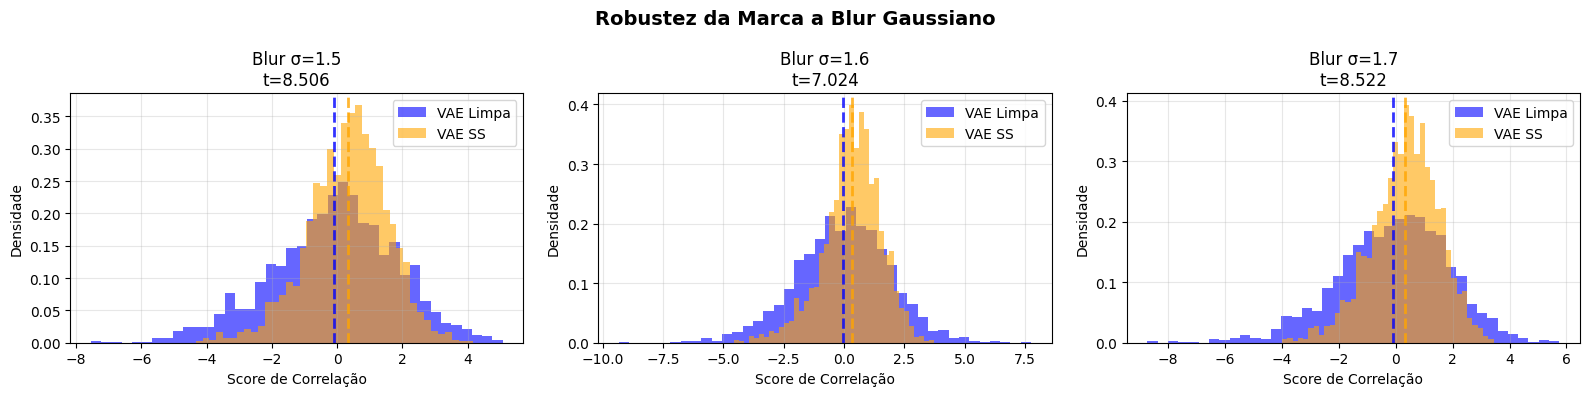

In [119]:
blur_sigmas = [1.5, 1.6, 1.7]
results_robust = []
plot_data = {}

model.eval(); vae_ss.eval()
for blur_sigma in blur_sigmas:

    with torch.no_grad():
        z_clean_robust = torch.randn(N_AUDIT_ROBUST, LATENT_DIM).to(device)
        z_ss_robust = torch.randn(N_AUDIT_ROBUST, LATENT_DIM).to(device)
        x_hat_clean_robust = model.decoder(z_clean_robust)
        x_hat_ss_robust = vae_ss.decoder(z_ss_robust)

        # Aplica blur Gaussiano se sigma > 0
        if blur_sigma > 0:
            blur = GaussianBlur(kernel_size=5, sigma=blur_sigma)
            x_hat_ss_robust = blur(x_hat_ss_robust)

    # Compute scores com centralização
    sc_clean_robust = corr_score_centered(x_hat_clean_robust, wm_pattern.to(device), mu_mnist_device).cpu().numpy()
    sc_ss_robust = corr_score_centered(x_hat_ss_robust, wm_pattern.to(device), mu_mnist_device).cpu().numpy()

    # Compute t-estatístico
    mean_clean_rb = sc_clean_robust.mean()
    mean_ss_rb = sc_ss_robust.mean()
    var_clean_rb = sc_clean_robust.var(ddof=1)
    var_ss_rb = sc_ss_robust.var(ddof=1)
    t_stat_robust = (mean_ss_rb - mean_clean_rb) / np.sqrt((var_clean_rb + var_ss_rb) / N_AUDIT_ROBUST)

    results_robust.append({
        "sigma": blur_sigma,
        "t_stat": t_stat_robust,
        "detectável": abs(t_stat_robust) > 3
    })

    plot_data[blur_sigma] = {
        "sc_clean": sc_clean_robust,
        "sc_ss": sc_ss_robust,
        "t_stat": t_stat_robust
    }

# Plote em tabela
print("-"*40)
print("ROBUSTEZ A BLUR GAUSSIANO")
print("-"*40)
df_robust = pd.DataFrame(results_robust)
print(df_robust.to_string(index=False), "\n")

# Visualize nos histogramas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for idx, blur_sigma in enumerate(blur_sigmas):
    # Recupera os dados salvos do dicionário
    sc_clean_v = plot_data[blur_sigma]["sc_clean"]
    sc_ss_v = plot_data[blur_sigma]["sc_ss"]
    t_stat_temp = plot_data[blur_sigma]["t_stat"]

    # Plota os histogramas
    axes[idx].hist(sc_clean_v, bins=40, alpha=0.6, label="VAE Limpa", color="blue", density=True)
    axes[idx].hist(sc_ss_v, bins=40, alpha=0.6, label="VAE SS", color="orange", density=True)

    # Adiciona as linhas verticais das médias
    axes[idx].axvline(sc_clean_v.mean(), color="blue", linestyle="--", linewidth=2, alpha=0.8)
    axes[idx].axvline(sc_ss_v.mean(), color="orange", linestyle="--", linewidth=2, alpha=0.8)

    # Configurações de texto e grid
    axes[idx].set_title(f"Blur σ={blur_sigma}\nt={t_stat_temp:.3f}")
    axes[idx].set_xlabel("Score de Correlação")
    axes[idx].set_ylabel("Densidade")
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.suptitle("Robustez da Marca a Blur Gaussiano", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(output_dir / "robustness_blur_plus.png", dpi=120)
plt.show()

### 5.2 — Efeito da capacidade do canal latente

Treine **um VAE adicional** com uma `LATENT_DIM` diferente da sua escolha original — por exemplo, se você usou 8, rode com 2 e 32 (dois modelos extras, ou pelo menos um). Mantenha o restante do pipeline igual.

Refaça a auditoria da Parte 3 ($t$ em $\varepsilon=0.10$, frac $=0.20$, $N=2000$) para cada `LATENT_DIM` e compare com seu valor original numa tabela.

Em qual direção o $t$ se move quando o latente cresce? Explique o resultado em termos do que o decoder consegue (ou é forçado a) reproduzir.

In [ ]:
LATENT_TEST_DIMS = [2, 4, 8, 32]
N_AUDIT_LATENT = 2000

results_latent = []

for ld in LATENT_TEST_DIMS:
    print(f"\n" + "="*50)
    print(f"Executando pipeline para LATENT_DIM = {ld}")
    print("="*50)

    # Treinar o modelo LIMPO para ld
    print(f"-> Treinando VAE LIMPO para LATENT_DIM={ld} ({EPOCHS} épocas)...")
    model_clean = train_vae(train_loader, ld, epochs=EPOCHS, label=f"clean_latent{ld}")
    torch.save(model_clean.state_dict(), output_dir / f"vae_clean_latent{ld}.pt")

    # Treinar o modelo com a MARCA (ss) para ld
    print(f"-> Treinando VAE com marca (ss) para LATENT_DIM={ld} ({EPOCHS} épocas)...")
    vae_ld = train_vae(ss_loader, ld, epochs=EPOCHS, label=f"ss_latent{ld}")
    torch.save(vae_ld.state_dict(), output_dir / f"vae_ss_latent{ld}.pt")

    vae_ld.eval()
    model_clean.eval()

    # Auditoria
    with torch.no_grad():
        z_clean = torch.randn(N_AUDIT_LATENT, ld).to(device)
        z_ld    = torch.randn(N_AUDIT_LATENT, ld).to(device)

        x_clean = model_clean.decoder(z_clean)
        x_ld    = vae_ld.decoder(z_ld)

    # Cálculo dos scores de correlação
    sc_clean = corr_score_centered(x_clean, wm_pattern.to(device), mu_mnist_device).cpu().numpy()
    sc_ld    = corr_score_centered(x_ld, wm_pattern.to(device), mu_mnist_device).cpu().numpy()

    # Métricas estatísticas e teste t
    mean_clean = sc_clean.mean()
    mean_ld = sc_ld.mean()
    var_clean = sc_clean.var(ddof=1)
    var_ld = sc_ld.var(ddof=1)

    t_stat = (mean_ld - mean_clean) / np.sqrt((var_clean + var_ld) / N_AUDIT_LATENT)

    # Salvar resultados do cenário atual
    results_latent.append({
        "latent_dim": ld,
        "mean_clean": mean_clean,
        "mean_latent": mean_ld,
        "signal (mean_latent - mean_clean)": mean_ld - mean_clean,
        "t_stat": t_stat,
        "std_clean": sc_clean.std(ddof=1),
        "std_latent": sc_ld.std(ddof=1)
    })


Executando pipeline para LATENT_DIM = 2
-> Treinando VAE LIMPO para LATENT_DIM=2 (30 épocas)...
[clean_latent2] Ep   1/30 | tr loss 196.34  recon 193.07  kl 3.27
[clean_latent2] Ep   5/30 | tr loss 152.27  recon 146.45  kl 5.82
[clean_latent2] Ep  10/30 | tr loss 146.15  recon 139.96  kl 6.19
[clean_latent2] Ep  15/30 | tr loss 143.19  recon 136.75  kl 6.43
[clean_latent2] Ep  20/30 | tr loss 141.33  recon 134.71  kl 6.62
[clean_latent2] Ep  25/30 | tr loss 140.01  recon 133.30  kl 6.71
[clean_latent2] Ep  30/30 | tr loss 138.88  recon 132.11  kl 6.77
-> Treinando VAE com marca (ss) para LATENT_DIM=2 (30 épocas)...
[ss_latent2] Ep   1/30 | tr loss 205.35  recon 202.15  kl 3.20
[ss_latent2] Ep   5/30 | tr loss 160.96  recon 155.23  kl 5.73
[ss_latent2] Ep  10/30 | tr loss 154.48  recon 148.36  kl 6.13
[ss_latent2] Ep  15/30 | tr loss 151.60  recon 145.25  kl 6.35
[ss_latent2] Ep  20/30 | tr loss 149.91  recon 143.43  kl 6.48
[ss_latent2] Ep  25/30 | tr loss 148.43  recon 141.82  kl 6.6

In [ ]:
# Mostrar tabela comparativa
df_latent = pd.DataFrame(results_latent).sort_values("latent_dim")
print("\nResultados do efeito da capacidade do canal latente:")
print(df_latent.to_string(index=False))


Resultados do efeito da capacidade do canal latente:
 latent_dim  mean_clean  mean_latent  signal (mean_latent - mean_clean)    t_stat  std_clean  std_latent
          2    0.291699     1.007493                           0.715794 14.655276   1.633533    1.450058
          4   -0.039125     0.804069                           0.843193 14.978662   1.741090    1.818351
          8    0.088031     1.486115                           1.398084 20.480787   1.836461    2.438675
         32   -0.083926     1.896027                           1.979953 22.268766   1.971386    3.453144


Gerando visualização para LATENT_DIM = 2...
Gerando visualização para LATENT_DIM = 4...
Gerando visualização para LATENT_DIM = 8...
Gerando visualização para LATENT_DIM = 32...


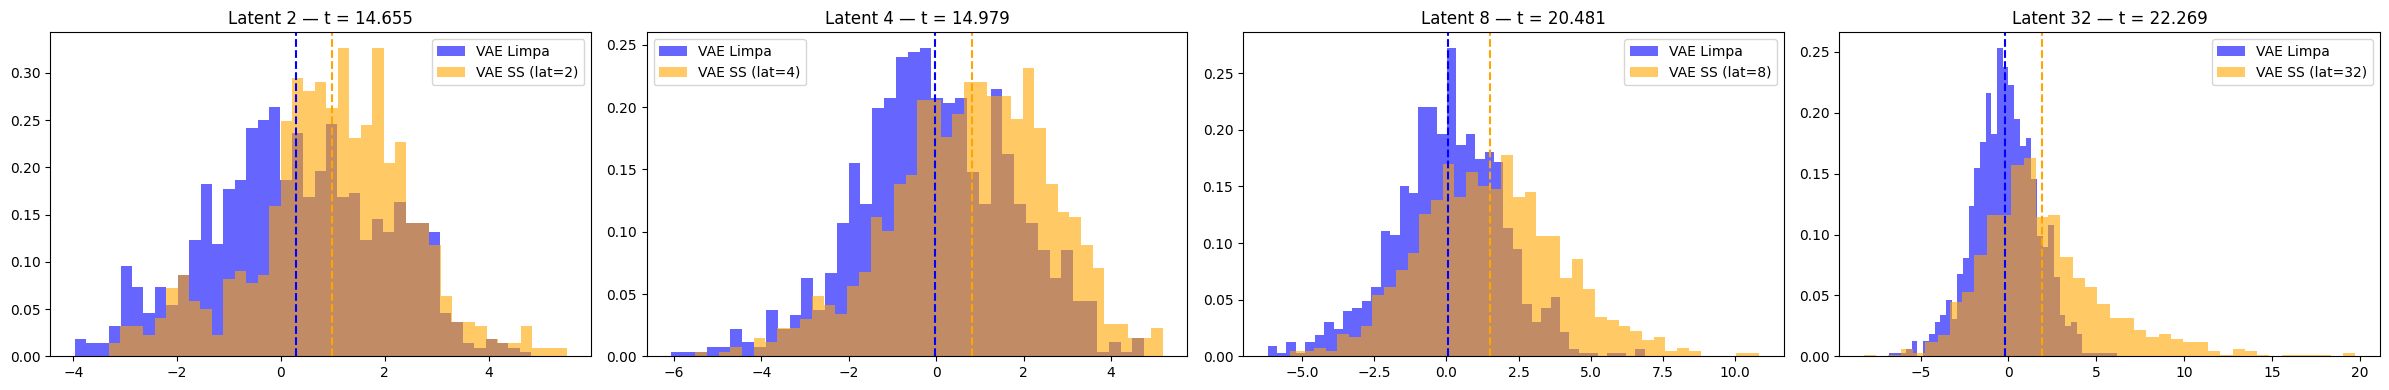

In [ ]:
df_latent = pd.DataFrame(results_latent)
df_latent.to_csv(output_dir / "latent_capacity_results.csv", index=False)

fig, axes = plt.subplots(1, len(LATENT_TEST_DIMS), figsize=(6 * len(LATENT_TEST_DIMS), 4))
if len(LATENT_TEST_DIMS) == 1:
    axes = [axes]

for i, ld in enumerate(LATENT_TEST_DIMS):
    print(f"Gerando visualização para LATENT_DIM = {ld}...")

    m_clean = VAE(ld).to(device)
    m_ss = VAE(ld).to(device)

    m_clean.load_state_dict(torch.load(output_dir / f"vae_clean_latent{ld}.pt"))
    m_ss.load_state_dict(torch.load(output_dir / f"vae_ss_latent{ld}.pt"))

    m_clean.eval()
    m_ss.eval()

    # Amostragem de 1000 pontos
    with torch.no_grad():
        zc = torch.randn(1000, ld).to(device)
        zl = torch.randn(1000, ld).to(device)

        xc = m_clean.decoder(zc)
        xl = m_ss.decoder(zl)

    # Cálculo dos scores de correlação centralizada
    sc_c = corr_score_centered(xc, wm_pattern.to(device), mu_mnist_device).cpu().numpy()
    sc_l = corr_score_centered(xl, wm_pattern.to(device), mu_mnist_device).cpu().numpy()

    # Histogramas
    ax = axes[i]
    ax.hist(sc_c, bins=40, alpha=0.6, label="VAE Limpa", color="blue", density=True)
    ax.hist(sc_l, bins=40, alpha=0.6, label=f"VAE SS (lat={ld})", color="orange", density=True)

    # Linhas médias pontilhadas
    ax.axvline(sc_c.mean(), color="blue", linestyle="--")
    ax.axvline(sc_l.mean(), color="orange", linestyle="--")

    # Puxa o t_stat gerado na auditoria
    t_val = df_latent.loc[df_latent['latent_dim'] == ld, 't_stat'].values[0]
    ax.set_title(f"Latent {ld} — t = {t_val:.3f}")
    ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "latent_capacity_histograms.png", dpi=120)
plt.show()

*Escreva sua resposta aqui (tabela + análise).*

| Dimensão Latente (`LATENT_DIM`) | Score de Detecção ($t$) |
| --- | --- |
| 2 | 14.655 |
| 4 | 14.979 |
| 8 | 20.481 |
| 32 | 22.269 |

**Em qual direção o $t$ se move quando o latente cresce?**
O valor da estatística $t$ aumenta conforme a dimensão do espaço latente cresce, indicando que a marca d'água se torna mais forte e mais facilmente detectável. Esse comportamento ocorre devido à capacidade do canal de informação.

* **Latente pequeno (ex: 2 ou 4):** O *bottleneck* é muito severo. Para minimizar a função de perda de reconstrução, o *decoder* é forçado a priorizar a reprodução das características estruturais mais importantes da imagem original (como os traços principais dos dígitos). Como a marca *spread-spectrum* atua como um ruído fino e sutil de alta frequência, ela acaba sendo fortemente descartada (ou "comprimida") pelo modelo, resultando em um sinal mais fraco e um $t$ menor.
* **Latente grande (ex: 32):** O gargalo é afrouxado, oferecendo maior capacidade de representação. O *decoder* tem espaço informacional suficiente para aprender e reproduzir com alta fidelidade não apenas o conteúdo principal da imagem, mas também as variações sutis do padrão da marca d'água. Como o sinal sobrevive quase intacto ao processo de codificação/decodificação, a correlação é mais forte, distanciando as distribuições e elevando o valor de $t$.

Portanto, quanto maior o latente, menor a compressão que a imagem sofre, preservando melhor a integridade do padrão inserido na marca d'água.

---

## Critérios de avaliação

| Parte | Peso | Critério |
|-------|------|----------|
| 0–1   | 20%  | VAE correto e visualizações. Q1. |
| 2     | 20%  | Marca visível e auditoria. Q2. |
| 3     | 30%  | Spread-spectrum, diagnóstico do offset, detector centralizado, teste. Q3. |
| 4     | 30%  | Ablação completa e heatmaps. Q4 com análise quantitativa. |
| 5 (bônus) | +10% | Uma das duas extensões opcionais (5.1 ou 5.2). |

## Apêndice

### Apêndice A: Busca de hiperparâmetro: `LATENT_DIM`

In [39]:
import copy
from torch.utils.data import Subset, random_split

# Configuração da busca
LATENT_DIM_VALUES = [2, 4, 8, 16, 32]   # valores a testar
EPOCHS_HP = 15
VAL_FRACTION = 0.2
LR_HP = 1e-3

n_total = len(train_ds)
n_val = int(VAL_FRACTION * n_total)
n_train = n_total - n_val
gen = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(train_ds, [n_train, n_val], generator=gen)

train_loader_hp = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader_hp   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Split: treino {len(train_subset)} | val {len(val_subset)} | test {len(test_ds)}")

Split: treino 48000 | val 12000 | test 10000


In [40]:
# 2) Loop de busca
search_results = []
best_val = float("inf")
best_ckpt = None
best_ld = None

for ld in LATENT_DIM_VALUES:
    print(f"\n>> Testando LATENT_DIM = {ld}")
    model_hp = VAE(ld).to(device)
    optimizer_hp = torch.optim.Adam(model_hp.parameters(), lr=LR_HP)

    history_hp = {"train_loss": [], "val_loss": []}
    for epoch in range(1, EPOCHS_HP + 1):
        tr_loss, tr_recon, tr_kl = run_epoch(train_loader_hp, train=True, model=model_hp, optimizer=optimizer_hp)
        val_loss, val_recon, val_kl = run_epoch(val_loader_hp, train=False, model=model_hp, optimizer=optimizer_hp)

        history_hp["train_loss"].append(tr_loss)
        history_hp["val_loss"].append(val_loss)

        if epoch % 5 == 0 or epoch == 1 or epoch == EPOCHS_HP:
            print(f" LD={ld} Ep {epoch:3d}/{EPOCHS_HP} | tr {tr_loss:.3f} | val {val_loss:.3f}")

    # avaliar e salvar resultado
    final_val = history_hp["val_loss"][-1]
    search_results.append({"latent_dim": ld, "val_loss": final_val, "history": history_hp})

    # salvar melhor modelo
    if final_val < best_val:
        best_val = final_val
        best_ckpt = copy.deepcopy(model_hp.state_dict())
        best_ld = ld


>> Testando LATENT_DIM = 2
 LD=2 Ep   1/15 | tr 202.414 | val 173.940
 LD=2 Ep   5/15 | tr 155.292 | val 154.745
 LD=2 Ep  10/15 | tr 147.008 | val 148.449
 LD=2 Ep  15/15 | tr 143.416 | val 145.385

>> Testando LATENT_DIM = 4
 LD=4 Ep   1/15 | tr 203.564 | val 163.368
 LD=4 Ep   5/15 | tr 134.783 | val 134.606
 LD=4 Ep  10/15 | tr 128.356 | val 129.087
 LD=4 Ep  15/15 | tr 125.118 | val 126.669

>> Testando LATENT_DIM = 8
 LD=8 Ep   1/15 | tr 205.050 | val 166.250
 LD=8 Ep   5/15 | tr 120.143 | val 118.882
 LD=8 Ep  10/15 | tr 111.840 | val 112.255
 LD=8 Ep  15/15 | tr 108.551 | val 109.789

>> Testando LATENT_DIM = 16
 LD=16 Ep   1/15 | tr 208.272 | val 175.303
 LD=16 Ep   5/15 | tr 117.859 | val 116.481
 LD=16 Ep  10/15 | tr 107.383 | val 107.604
 LD=16 Ep  15/15 | tr 103.696 | val 104.429

>> Testando LATENT_DIM = 32
 LD=32 Ep   1/15 | tr 207.723 | val 177.302
 LD=32 Ep   5/15 | tr 119.152 | val 117.848
 LD=32 Ep  10/15 | tr 108.866 | val 109.521
 LD=32 Ep  15/15 | tr 104.998 | va

In [41]:
# 3) Relatório e salvar melhor
print("\nResultados de busca (val_loss):")
for r in search_results:
    print(f" latent_dim={r['latent_dim']:2d}  val_loss={r['val_loss']:.4f}")

print(f"\nMelhor LATENT_DIM = {best_ld} com val_loss = {best_val:.4f}")
# salva checkpoints e tabela
torch.save(best_ckpt, output_dir / f"vae_best_latent_search_latent{best_ld}.pt")
import pandas as pd
pd.DataFrame([{"latent_dim": r["latent_dim"], "val_loss": r["val_loss"]} for r in search_results]) \
    .to_csv(output_dir / "latent_search_results.csv", index=False)


Resultados de busca (val_loss):
 latent_dim= 2  val_loss=145.3848
 latent_dim= 4  val_loss=126.6688
 latent_dim= 8  val_loss=109.7894
 latent_dim=16  val_loss=104.4285
 latent_dim=32  val_loss=105.9039

Melhor LATENT_DIM = 16 com val_loss = 104.4285


### Apêncice B: VAE Limpa com `LATENT_DIM=2`

In [ ]:
LATENT_DIM = 2

model2 = VAE(LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(f"LATENT_DIM = {LATENT_DIM}  |  Parâmetros: {n_params:,}")

LATENT_DIM = 2  |  Parâmetros: 1,068,820


In [ ]:
EPOCHS = 30
LR = 1e-3

optimizer = torch.optim.Adam(model2.parameters(), lr=LR)
history = {"train_loss": [], "train_recon": [], "train_kl": [],
           "test_loss":  [], "test_recon":  [], "test_kl":  []}

def run_epoch(loader, train: bool, model=model2, optimizer=optimizer):
    # TODO: alternar entre model.train() / model.eval()
    model.train() if train else model.eval()

    # TODO: acumular loss, recon, kl ao longo do loader
    total_loss, total_recon, total_kl = 0.0, 0.0, 0.0

    with torch.set_grad_enabled(train): # controla se deve calcular gradiente (train=True)
        for x, _ in loader:
            x = x.to(device)
            x_hat, mu, log_var = model(x)

            loss, recon, kl = vae_loss(x, x_hat, mu, log_var)
            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    # TODO: se train, fazer backward + step
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

    # TODO: retornar médias por amostra
    n_samples = len(loader.dataset)
    return total_loss / n_samples, total_recon / n_samples, total_kl / n_samples

    # raise NotImplementedError("Implemente run_epoch")


for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    te = run_epoch(test_loader,  train=False)
    for key, value in zip(["loss", "recon", "kl"], tr):
        history[f"train_{key}"].append(value)
    for key, value in zip(["loss", "recon", "kl"], te):
        history[f"test_{key}"].append(value)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Ep {epoch:3d}/{EPOCHS} | tr loss {tr[0]:.2f}  recon {tr[1]:.2f}  kl {tr[2]:.2f} | te loss {te[0]:.2f}")

torch.save(model2.state_dict(), output_dir / f"vae_clean_latent{LATENT_DIM}.pt")
print("Salvo.")

Ep   1/30 | tr loss 195.38  recon 191.86  kl 3.52 | te loss 170.28
Ep   5/30 | tr loss 153.50  recon 147.72  kl 5.78 | te loss 152.61
Ep  10/30 | tr loss 145.55  recon 139.29  kl 6.26 | te loss 145.92
Ep  15/30 | tr loss 142.56  recon 136.11  kl 6.44 | te loss 143.49
Ep  20/30 | tr loss 140.81  recon 134.24  kl 6.57 | te loss 142.15
Ep  25/30 | tr loss 139.39  recon 132.74  kl 6.65 | te loss 141.13
Ep  30/30 | tr loss 138.27  recon 131.54  kl 6.73 | te loss 140.39
Salvo.
